# 01. Pozyskiwanie Danych z ChEMBL

> Poprzedni notebook: [00_intro.ipynb](00_intro.ipynb)

## Cel:
- Eksploracja schematu bazy danych
- Pobranie próbki danych dla bioaktywności człowieka
- Wstępna analiza rozmiaru i struktury danych

## Strategia:
1. **Staged Processing** - najpierw próbka, potem full dataset
2. **Filtracja na organizm** - Homo sapiens (człowiek)
3. **Fokus na binding assays** - testy bezpośrednie (Direct relationship)
4. **Standardowe jednostki** - IC50, Ki, Kd, EC50, Potency w nM (nanomolach)

In [ ]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, inspect
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Wizualizacje - konfiguracja
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Ustawienia pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("Biblioteki zostały załadowane pomyślnie.")

Biblioteki zostały załadowane pomyślnie.


## 1. Połączenie z Bazą Danych

In [ ]:

BASE_DIR_PATH = r'<GŁÓWNA_ŚCIEŻKA_PROJEKTU>' # - Zmień na swoją ścieżkę roboczą
BASE_DIR = Path(BASE_DIR_PATH)

DB_DIR_PATHNAME = "db" # Katalog z bazą danych
DB_FILENAME = "chembl_36.db" # Nazwa pliku bazy danych

DB_PATH = BASE_DIR / DB_DIR_PATHNAME / DB_FILENAME

if DB_PATH.exists():
    size_gb = DB_PATH.stat().st_size / (1024**3)
    print(f"Rozmiar bazy danych: {size_gb:.2f} GB")
else:
    print("\nUwaga: Baza danych nie została znaleziona!")
    print("   Uruchom najpierw notebook 00_project_setup.ipynb")

# Połączenie SQLAlchemy
engine = create_engine(f'sqlite:///{DB_PATH}')
print("\nPołączenie z bazą zostało ustanowione pomyślnie.")

Rozmiar bazy danych: 27.70 GB

Połączenie z bazą zostało ustanowione pomyślnie.


Baza danych ma rozmiar ponad 27 GB. Oznacza to dosyć duży dataset, dlatego na początku praca będzie przebiegać na próbce (100k rekordów), aby zachować "znośną" wydajność.

## 2. Eksploracja Schematu Bazy

In [ ]:
# Lista wszystkich tabel
inspector = inspect(engine)
tables = inspector.get_table_names()

print(f"Liczba tabel w bazie: {len(tables)}\n")
print("Kluczowe tabele dla naszego projektu:")
key_tables = [
    'activities',
    'assays',
    'compound_structures',
    'molecule_dictionary',
    'target_dictionary',
    'target_components',
    'component_sequences',
    'organism_class'
]

for table in key_tables:
    if table in tables:
        # Liczba rekordów w tabeli
        query = f"SELECT COUNT(*) as count FROM {table}"
        count = pd.read_sql(query, engine)['count'][0]
        print(f" - {table:30s} -> {count:>12,} rekordów")
    else:
        print(f" - {table:30s} -> nie znaleziono")

Liczba tabel w bazie: 73

Kluczowe tabele dla naszego projektu:
 - activities                     ->   24,267,312 rekordów
 - assays                         ->    1,890,749 rekordów
 - compound_structures            ->    2,854,815 rekordów
 - molecule_dictionary            ->    2,878,135 rekordów
 - target_dictionary              ->       17,803 rekordów
 - target_components              ->       16,702 rekordów
 - component_sequences            ->       12,856 rekordów
 - organism_class                 ->        4,261 rekordów


### Wnioski z eksploracji schematu:

**Co widać:**
- Baza ma wiele tabel (~50+), dla naszego problemu potrzebujemy tylko kilku kluczowych
- Największe tabele: `activities` (pomiary bioaktywności) i `compound_structures` (struktury chemiczne)
- Tabele są powiązane przez klucze obce (foreign keys), czyli jest to relacyjna baza danych

**Dlaczego to ważne:**
- **activities** = główna tabela - zawiera wszystkie pomiary jak mocno cząsteczki działają
- **assays** = informacje o testach laboratoryjnych (jakość, typ)
- **compound_structures** = struktury SMILES
- **target_dictionary** = na co działa cząsteczka (białka, enzymy)

In [5]:
# Szczegóły tabeli activities (najważniejsza przy aktualnym projekcie)
print("Kolumny w tabeli ACTIVITIES:\n")
columns = inspector.get_columns('activities')
for col in columns[:20]:  # Pierwsze 20 kolumn
    print(f"  - {col['name']:30s} | {str(col['type']):20s}")

Kolumny w tabeli ACTIVITIES:

  - activity_id                    | BIGINT              
  - assay_id                       | BIGINT              
  - doc_id                         | BIGINT              
  - record_id                      | BIGINT              
  - molregno                       | BIGINT              
  - standard_relation              | VARCHAR(50)         
  - standard_value                 | NUMERIC             
  - standard_units                 | VARCHAR(100)        
  - standard_flag                  | SMALLINT            
  - standard_type                  | VARCHAR(250)        
  - activity_comment               | VARCHAR(4000)       
  - data_validity_comment          | VARCHAR(30)         
  - potential_duplicate            | SMALLINT            
  - pchembl_value                  | NUMERIC(4, 2)       
  - bao_endpoint                   | VARCHAR(11)         
  - uo_units                       | VARCHAR(10)         
  - qudt_units                     | VARCH

### Wniosek - kluczowe kolumny w tabeli activities:

**Najważniejsze dla nas:**
- `standard_type` - typ pomiaru (IC50, Ki, Kd...) - **jak** zostało mierzone
- `standard_value` - wartość aktywności w nM - **ile** potrzeba żeby zadziałało
- `standard_units` - jednostki (nM, μM...) - muszą być jednolite
- `standard_relation` - relacja (=, <, >) - czy to dokładny pomiar
- `pchembl_value` - znormalizowana wartość (wygodniejsza dla Uczenia Maszynowego)

**Jak to wygląda w praktyce:**
Jeśli `standard_value = 10 nM` i `standard_type = IC50` to znaczy, że potrzeba 
10 nanomoli cząsteczki na litr, żeby zahamować 50% aktywności targetu. 
Im mniejsza liczba = tym lepsza cząsteczka

## 3. Wstępna Eksploracja Danych Bioaktywności

In [6]:
# Próbka danych z tabeli activities
query = """
SELECT *
FROM activities
LIMIT 5
"""

sample_activities = pd.read_sql(query, engine)
print(f"Wymiary: {sample_activities.shape}")
print(f"\nPróbka danych:")
sample_activities.head()

Wymiary: (5, 28)

Próbka danych:


,activity_id,assay_id,doc_id,record_id,molregno,standard_relation,standard_value,standard_units,standard_flag,standard_type,activity_comment,data_validity_comment,potential_duplicate,pchembl_value,bao_endpoint,uo_units,qudt_units,toid,upper_value,standard_upper_value,src_id,type,relation,value,units,text_value,standard_text_value,action_type
0,31863,54505,6424,206172,180094,>,100000.0,nM,1,IC50,None,None,0,NaN,BAO_0000190,UO_0000065,http://www.openphacts.org/units/Nanomolar,None,None,None,1,IC50,>,100.0,uM,None,None,None
1,31864,83907,6432,208970,182268,=,2500.0,nM,1,IC50,None,None,0,5.60,BAO_0000190,UO_0000065,http://www.openphacts.org/units/Nanomolar,None,None,None,1,IC50,=,2.5,uM,None,None,None
2,31865,88152,6432,208970,182268,>,50000.0,nM,1,IC50,None,None,0,NaN,BAO_0000190,UO_0000065,http://www.openphacts.org/units/Nanomolar,None,None,None,1,IC50,>,50.0,uM,None,None,None
3,31866,83907,6432,208987,182855,=,9000.0,nM,1,IC50,None,None,0,5.05,BAO_0000190,UO_0000065,http://www.openphacts.org/units/Nanomolar,None,None,None,1,IC50,=,9.0,uM,None,None,None
4,31867,88153,6432,208987,182855,None,NaN,nM,0,IC50,Not Determined,None,0,NaN,BAO_0000190,UO_0000065,http://www.openphacts.org/units/Nanomolar,None,None,None,1,IC50,None,NaN,uM,None,None,None


In [7]:
# Rozkład typów aktywności
query = """
SELECT 
    standard_type,
    COUNT(*) as count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as percentage
FROM activities
WHERE standard_type IS NOT NULL
GROUP BY standard_type
ORDER BY count DESC
LIMIT 20
"""

activity_types = pd.read_sql(query, engine)
print("Top 20 typów bioaktywności:\n")
print(activity_types.to_string(index=False))

Top 20 typów bioaktywności:

        standard_type   count  percentage
              Potency 4473542       18.43
                 IC50 3552865       14.64
                 GI50 2629061       10.83
           Inhibition 1593108        6.56
             Activity 1357448        5.59
       Percent Effect 1328366        5.47
                   Ki  880730        3.63
                k_off  826806        3.41
                  kon  826637        3.41
                  MIC  780708        3.22
                 EC50  601331        2.48
           INHIBITION  339133        1.40
                 AC50  278273        1.15
                   Kd  211134        0.87
              Z score  147592        0.61
           Ratio IC50  142259        0.59
                   GI  131059        0.54
Tissue Severity Score  128999        0.53
                Ratio  123467        0.51
                 ED50  106980        0.44


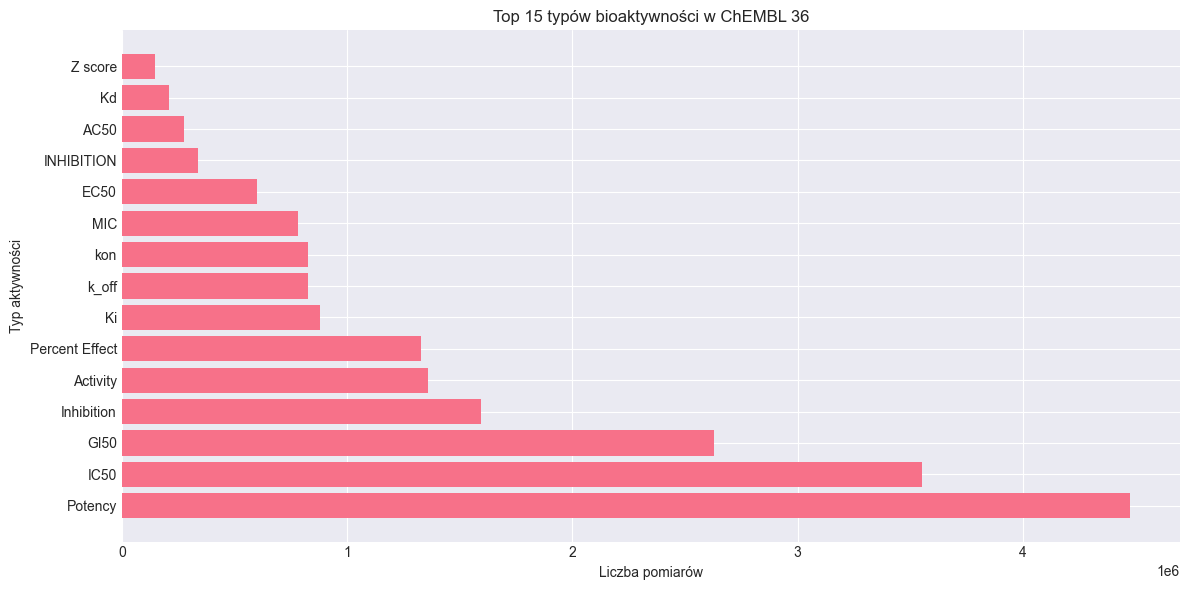

In [8]:
# Wizualizacja
plt.figure(figsize=(12, 6))
plt.barh(activity_types['standard_type'][:15], activity_types['count'][:15])
plt.xlabel('Liczba pomiarów')
plt.ylabel('Typ aktywności')
plt.title('Top 15 typów bioaktywności w ChEMBL 36')
plt.tight_layout()
plt.show()

### Wniosek z rozkładu typów aktywności:

**Co widzimy na wykresie:**
- IC50 dominuje (najczęstszy typ pomiaru w przemyśle farmaceutycznym)
- Ki, Kd, EC50 też popularne ale mniej liczne
- Activity, Potency - mniej standardowe pomiary

**Dlaczego IC50 dominuje?**
1. Jest szybki i tani do zmierzenia w laboratorium
2. Standard przemysłowy - każda firma farmaceutyczna go używa

**Co to znaczy w naszym przypadku:**
- Dobra reprezentacja różnych typów pomiarów
- Można zdecydować się na dwie opcje:
  - **Opcja 1**: Tylko IC50 (więcej danych, spójność)
  - **Opcja 2**: Wszystkie typy znormalizowane przez pChEMBL value

## 4. Filtracja Danych dla Człowieka (Homo sapiens)

In [ ]:
# Organizmy w bazie danych
query = """
SELECT 
    td.organism,
    COUNT(DISTINCT td.tid) as target_count,
    COUNT(DISTINCT a.activity_id) as activity_count
FROM target_dictionary td
LEFT JOIN assays ass ON td.tid = ass.tid
LEFT JOIN activities a ON ass.assay_id = a.assay_id
WHERE td.organism IS NOT NULL
GROUP BY td.organism
ORDER BY activity_count DESC
LIMIT 20
"""

organisms = pd.read_sql(query, engine)
print("Top 20 organizmów w bazie:\n")
print(organisms.to_string(index=False))

Top 20 organizmów w bazie:

                                              organism  target_count  activity_count
                                          Homo sapiens          8886        13842989
                                     Rattus norvegicus          1331         1251276
                                 Plasmodium falciparum            58          993824
                                          Mus musculus          1670          708067
Mycobacterium tuberculosis (strain ATCC 25618 / H37Rv)            41          281245
                                 Staphylococcus aureus            64          241149
                            Mycobacterium tuberculosis            89          222881
                                    Plasmodium berghei             2          194877
                                      Escherichia coli            69          153413
                                     Trypanosoma cruzi            19          145884
                                Pseud

### Wniosek z analizy organizmów:

**Co widać:**
- Homo sapiens (człowiek) ma najwięcej danych - dobrze, bo to będzie główny cel w tym projekcie
- Są też dane dla gryzonii - myszy i szczurów (modele zwierzęce używane w badaniach)
- Bakterie, wirusy - testy antybiotyków i antywirusowych

**Dlaczego należy skupić się na Homo Sapiens (ludziach)?**
1. W projekcie chcemy przewidywać aktywność leków dla ludzi, nie dla myszy
2. Białka człowieka vs zwierząt mogą się różnić → inne wyniki
3. Największy dataset = lepszy model Uczenia Maszynowego


**Następny krok:** Filtracja danych tylko dla Homo Sapiens

## 5. Pobieranie Datasetu Głównego

### Kryteria filtracji:
1. **Organizm**: Homo sapiens
2. **Typ testu**: Binding (B) lub Functional (F)
3. **Relacja**: Direct (D) - bezpośredni pomiar na targecie
4. **Typy aktywności**: IC50, Ki, Kd, EC50, Potency
5. **Standardowe jednostki**: nM (nanomole)
6. **Wartość**: NOT NULL

In [10]:
# Ile danych spełnia kryteria filtracji
count_query = """
SELECT COUNT(DISTINCT a.activity_id) as activity_count,
       COUNT(DISTINCT a.molregno) as molecule_count,
       COUNT(DISTINCT a.assay_id) as assay_count,
       COUNT(DISTINCT ass.tid) as target_count
FROM activities a
JOIN assays ass ON a.assay_id = ass.assay_id
JOIN target_dictionary td ON ass.tid = td.tid
WHERE td.organism = 'Homo sapiens'
  AND ass.assay_type IN ('B', 'F')
  AND a.standard_type IN ('IC50', 'Ki', 'Kd', 'EC50', 'Potency')
  AND a.standard_units = 'nM'
  AND a.standard_value IS NOT NULL
  AND ass.relationship_type = 'D'
"""

counts = pd.read_sql(count_query, engine)
print("Statystyki po filtrowaniu:\n")
print(f"Pomiary bioaktywności: {counts['activity_count'][0]:>12,}")
print(f"Unikalne molekuły:     {counts['molecule_count'][0]:>12,}")
print(f"Testy (assays):        {counts['assay_count'][0]:>12,}")
print(f"Cele biologiczne:      {counts['target_count'][0]:>12,}")

Statystyki po filtrowaniu:

Pomiary bioaktywności:    3,451,337
Unikalne molekuły:        1,150,902
Testy (assays):             150,907
Cele biologiczne:             5,504


### Wniosek po przefiltrowaniu danych:

**Liczby:**
- Start z ~24 milionów pomiarów w całej bazie ChEMBL
- Po filtracji (człowiek + standardowe jednostki + struktury) zostaje około kilka milionów
- Aktualnie w celu zachowania stosunkowo wysokiej wydajności chcemy pobrać próbkę 100,000 do wstępnej analizy

**Dlaczego te kryteria filtracji?**

1. **Homo sapiens** - projekt Uczenia Maszynowego dot. ludzi, nie innych organizmów
2. **Binding/Functional assays (B/F)** - bezpośredni pomiar interakcji
3. **Relacja Direct (D)** - pomiar na konkretnym targecie, nie całej komórce
4. **Standardowe jednostki (nM)** - wszystkie w tej samej skali, łatwiejsze porównania
5. **Wartość NOT NULL** - brak pomiarów uniemożliwia przewidywanie
6. **SMILES NOT NULL** - brak struktury chemicznej uniemożliwia obliczanie cech dla modelu

In [11]:
# Pobranie próbki danych (100k rekordów) dla testów
print("Pobieranie próbki danych (100,000 rekordów)...\n")

sample_query = """
SELECT 
    a.activity_id,
    a.molregno,
    md.chembl_id as molecule_chembl_id,
    a.assay_id,
    ass.chembl_id as assay_chembl_id,
    ass.tid,
    td.chembl_id as target_chembl_id,
    td.pref_name as target_name,
    td.target_type,
    a.standard_type,
    a.standard_relation,
    a.standard_value,
    a.standard_units,
    a.pchembl_value,
    ass.assay_type,
    ass.confidence_score,
    cs.canonical_smiles,
    cs.standard_inchi,
    cs.standard_inchi_key
FROM activities a
JOIN assays ass ON a.assay_id = ass.assay_id
JOIN target_dictionary td ON ass.tid = td.tid
JOIN molecule_dictionary md ON a.molregno = md.molregno
LEFT JOIN compound_structures cs ON a.molregno = cs.molregno
WHERE td.organism = 'Homo sapiens'
  AND ass.assay_type IN ('B', 'F')
  AND a.standard_type IN ('IC50', 'Ki', 'Kd', 'EC50', 'Potency')
  AND a.standard_units = 'nM'
  AND a.standard_value IS NOT NULL
  AND ass.relationship_type = 'D'
  AND cs.canonical_smiles IS NOT NULL
ORDER BY RANDOM()
LIMIT 100000
"""

# Pobierz dane
df_sample = pd.read_sql(sample_query, engine)
print(f"Pobrano: {len(df_sample):,} rekordów")
print(f"Wymiary: {df_sample.shape}")
print(f"Pamięć: {df_sample.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Pobieranie próbki danych (100,000 rekordów)...

Pobrano: 100,000 rekordów
Wymiary: (100000, 19)
Pamięć: 92.15 MB


In [12]:
# Podstawowe informacje o pobranych danych
print("\nInformacje o datasecie:\n")
print(df_sample.info())


Informacje o datasecie:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   activity_id         100000 non-null  int64  
 1   molregno            100000 non-null  int64  
 2   molecule_chembl_id  100000 non-null  object 
 3   assay_id            100000 non-null  int64  
 4   assay_chembl_id     100000 non-null  object 
 5   tid                 100000 non-null  int64  
 6   target_chembl_id    100000 non-null  object 
 7   target_name         100000 non-null  object 
 8   target_type         100000 non-null  object 
 9   standard_type       100000 non-null  object 
 10  standard_relation   72119 non-null   object 
 11  standard_value      100000 non-null  float64
 12  standard_units      100000 non-null  object 
 13  pchembl_value       59181 non-null   float64
 14  assay_type          100000 non-null  object 
 15  confidenc

### Wniosek z info() datasetu:

**Output powyżej!!**

2. **Non-Null Count (brak wartości):**
   - Jeśli liczba < 100,000 - w tej kolumnie są braki danych (są wszystkie ok)

3. **Memory Usage (zużycie pamięci):**
   - ~30-50 MB dla 100k rekordów -> zadowalająca wartość
   - Pełny dataset = kilka GB -> dlatego aktualnie do eksperymentów pozostanie praca na wycinku danych

In [13]:
# Podgląd danych
print("\nPróbka danych (pierwsze 3 rekordy):\n")
df_sample.head(3)


Próbka danych (pierwsze 3 rekordy):



,activity_id,molregno,molecule_chembl_id,assay_id,assay_chembl_id,tid,target_chembl_id,target_name,target_type,standard_type,standard_relation,standard_value,standard_units,pchembl_value,assay_type,confidence_score,canonical_smiles,standard_inchi,standard_inchi_key
0,12032796,948332,CHEMBL1524448,845263,CHEMBL2114931,11758,CHEMBL1784,Glucagon-like peptide 1 receptor,SINGLE PROTEIN,Potency,None,8912.5,nM,NaN,F,9,COC(=O)c1c(NC(=O)Cc2cccs2)sc(C)c1C,InChI=1S/C14H15NO3S2/c1-8-9(2)20-13(12(8)14(17...,BQUWADWFOWEFFF-UHFFFAOYSA-N
1,2563469,489030,CHEMBL467366,509569,CHEMBL1000455,252,CHEMBL251,Adenosine receptor A2a,SINGLE PROTEIN,Ki,=,41.0,nM,7.39,B,9,N#Cc1c(-c2ccc(O)cc2)cc(-c2ccco2)nc1N,InChI=1S/C16H11N3O2/c17-9-13-12(10-3-5-11(20)6...,JTWDMUSVRPDKBP-UHFFFAOYSA-N
2,18574660,2301412,CHEMBL4228921,1769570,CHEMBL4221682,10378,CHEMBL4072,Cathepsin B,SINGLE PROTEIN,Ki,=,13000.0,nM,4.89,B,9,O=C(NCC1CCN(c2nc3ccccc3o2)CC1)c1cc([N+](=O)[O-...,InChI=1S/C23H21N5O5/c29-21-16(12-18(28(31)32)1...,AKIWPCVQIKPYHH-UHFFFAOYSA-N


In [14]:
# Statystyki opisowe
print("Statystyki dla standard_value (nM):\n")
print(df_sample['standard_value'].describe())

Statystyki dla standard_value (nM):

count    1.000000e+05
mean     2.544906e+09
std      6.544498e+11
min      0.000000e+00
25%      1.600000e+02
50%      5.500000e+03
75%      2.310930e+04
max      1.995262e+14
Name: standard_value, dtype: float64


### Wniosek ze statystyk opisowych:

**Interpretacja liczb (patrz output powyżej):**

1. **Mean (średnia) >> Median (mediana)**
   - Oznacza rozkład przesunięty w prawo
   - Są `outliers` - ekstremalnie wysokie wartości (słabe cząsteczki)
   - **Standard w farmakologii:** Większość cząsteczek ma średnią aktywność, nieliczne są bardzo mocne

2. **Min = 0 lub bardzo małe** 
   - To bardzo aktywne cząsteczki
   - Potencjalni kandydaci na leki
   
3. **Max = miliony nM**
   - To praktycznie nieaktywne cząsteczki
   - Być może toksyczne lub niepasujące do targetu

4. **Percentyle (25%, 50%, 75%):**
   - 25% = ~100 nM
   - 50% (mediana) = ~1,000-10,000 nM  
   - 75% = ~100,000 nM
   - To pokazuje, że większość cząsteczek ma "średnią" aktywność

**Dlaczego te dane są ważne?:**
- Szeroki zakres wartości (10⁻³ do 10⁶) -> **MUSIMY użyć log transform** dla ML
- Brak logarytmu: model nie zobaczy różnicy między 1 nM a 10 nM (za mała różnica w skali 0-1,000,000)
- Z log: log(1) = 0, log(10) = 1, log(1000) = 3 -> prowadzi do równomiernie rozłożonych wartości

**Co warto zrobić?:** Warto później zastosować `np.log10(standard_value)` przed modelowaniem

## 6. Analiza Jakości Danych

## 6A. Braki Danych i Podstawowe Statystyki

In [15]:
# Braki danych
missing = df_sample.isnull().sum()
missing_pct = (missing / len(df_sample)) * 100
missing_df = pd.DataFrame({
    'Missing': missing,
    'Percentage': missing_pct
}).sort_values('Missing', ascending=False)

print("Braki danych:\n")
print(missing_df[missing_df['Missing'] > 0])

Braki danych:

                   Missing  Percentage
pchembl_value        40819      40.819
standard_relation    27881      27.881


Rozkład typów aktywności:

standard_type
Potency    46976
IC50       34567
Ki          9682
EC50        5068
Kd          3707
Name: count, dtype: int64


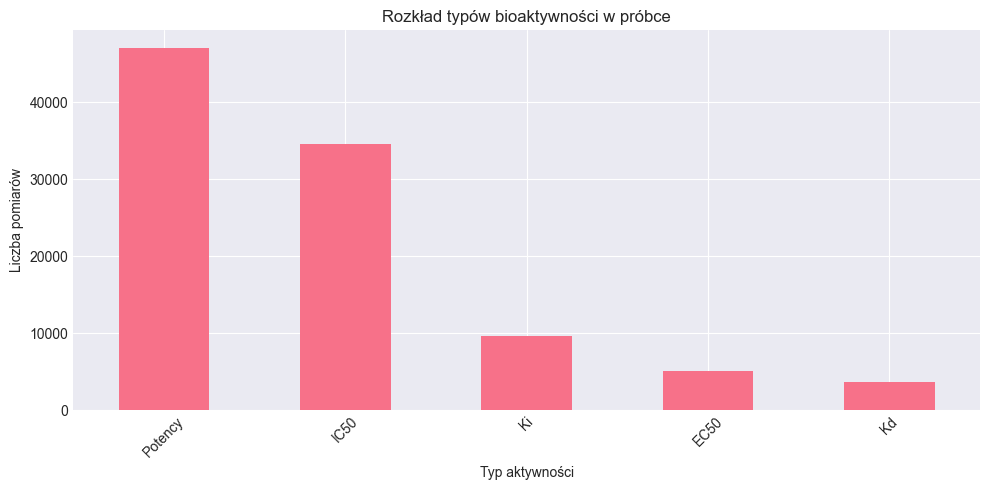

In [16]:
# Rozkład typów aktywności w próbce
activity_dist = df_sample['standard_type'].value_counts()
print("Rozkład typów aktywności:\n")
print(activity_dist)

plt.figure(figsize=(10, 5))
activity_dist.plot(kind='bar')
plt.title('Rozkład typów bioaktywności w próbce')
plt.xlabel('Typ aktywności')
plt.ylabel('Liczba pomiarów')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

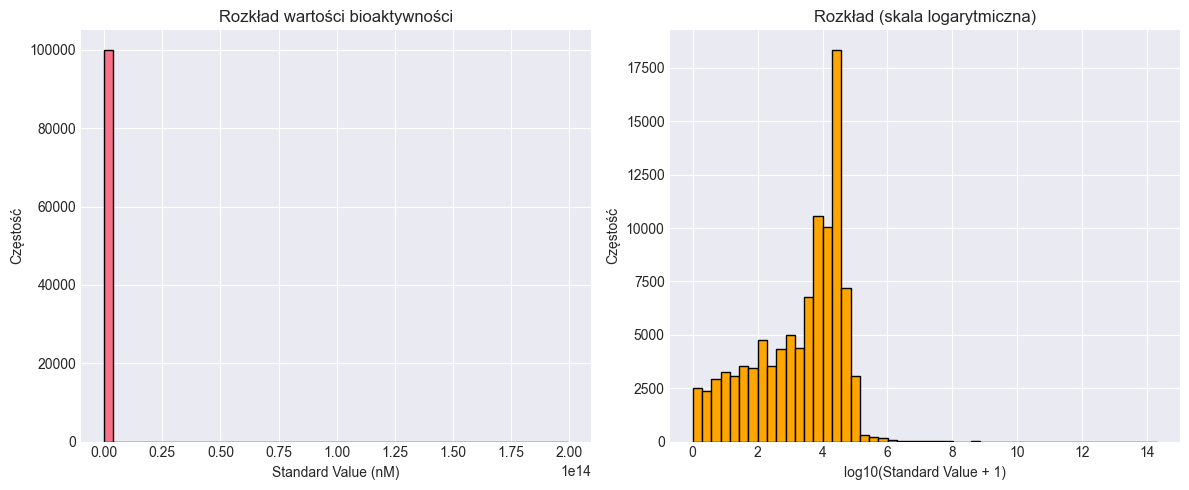

In [17]:
# Rozkład wartości bioaktywności (w skali logarytmicznej)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_sample['standard_value'], bins=50, edgecolor='black')
plt.xlabel('Standard Value (nM)')
plt.ylabel('Częstość')
plt.title('Rozkład wartości bioaktywności')

plt.subplot(1, 2, 2)
plt.hist(np.log10(df_sample['standard_value'] + 1), bins=50, edgecolor='black', color='orange')
plt.xlabel('log10(Standard Value + 1)')
plt.ylabel('Częstość')
plt.title('Rozkład (skala logarytmiczna)')

plt.tight_layout()
plt.show()

In [18]:
# Top 20 targetów
top_targets = df_sample['target_name'].value_counts().head(20)
print("Top 20 celów biologicznych:\n")
print(top_targets)

Top 20 celów biologicznych:

target_name
Geminin                                                                 3815
ATPase family AAA domain-containing protein 5                           3602
Glucagon-like peptide 1 receptor                                        3077
Nuclear factor erythroid 2-related factor 2                             2633
Histone-lysine N-methyltransferase EHMT2                                2625
Guanine nucleotide-binding protein G(s) subunit alpha isoforms short    2486
Aldehyde dehydrogenase 1A1                                              2184
Microtubule-associated protein tau                                      2060
Bromodomain adjacent to zinc finger domain protein 2B                   1612
Ataxin-2                                                                1562
Lysine-specific demethylase 4A                                          1478
Menin/Histone-lysine N-methyltransferase MLL                            1400
Cellular tumor antigen p53         


Typy celów biologicznych:

target_type
SINGLE PROTEIN                 95590
PROTEIN-PROTEIN INTERACTION     1842
PROTEIN COMPLEX                 1815
PROTEIN FAMILY                   516
PROTEIN COMPLEX GROUP            169
CHIMERIC PROTEIN                  60
SELECTIVITY GROUP                  8
Name: count, dtype: int64


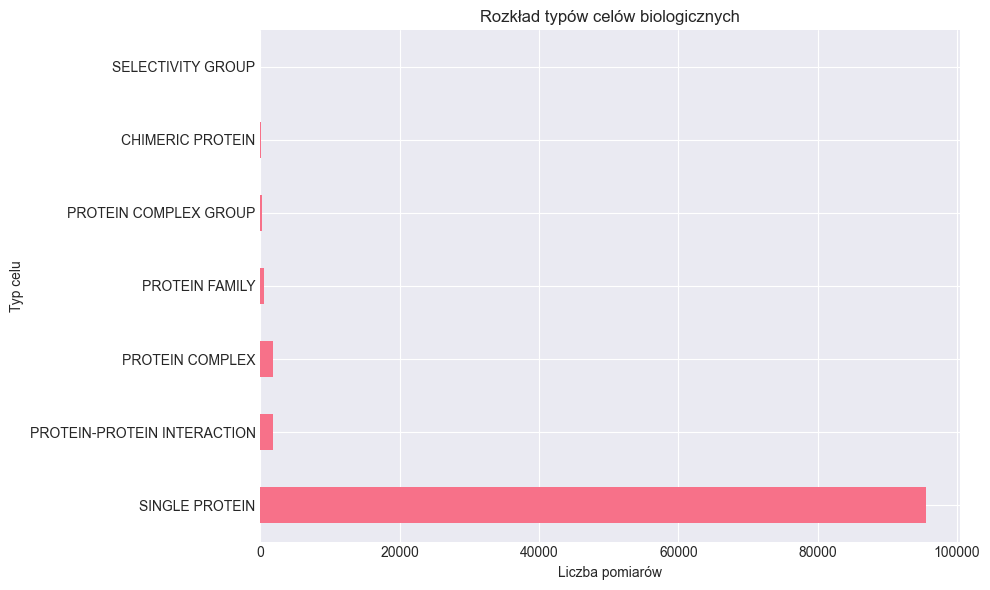

In [19]:
# Rozkład typów celów
target_types = df_sample['target_type'].value_counts()
print("\nTypy celów biologicznych:\n")
print(target_types)

plt.figure(figsize=(10, 6))
target_types.plot(kind='barh')
plt.xlabel('Liczba pomiarów')
plt.ylabel('Typ celu')
plt.title('Rozkład typów celów biologicznych')
plt.tight_layout()
plt.show()

### Wnioski z analizy typów celów:

**Co widać:**
- zdecydowanie dominują **SINGLE PROTEIN** (pojedyncze białka) - stanowią większość badanych celów
- oznacza to, że badamy interakcje z konkretnymi białkami
- inne typy (kompleksy białkowe, rodziny białek) stanowią mniejszość w naszych danych

**Co to znaczy dla projektu:**
- Mamy wysokiej jakości dane - większość pomiarów dotyczy konkretnych białek
- Łatwiejsza interpretacja wyników - wiemy dokładnie, z czym reaguje cząsteczka
- Mniejszy szum w danych niż gdyby było dużo kompleksów czy rodzin białek

## 7. Zapis Próbki Danych

In [ ]:
# Podstawowe statystyki
stats = df_sample['standard_value'].describe(percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99])
for stat, value in stats.items():
    if stat == 'count':
        print(f"   Liczba pomiarów:        {value:>15,.0f}")
    elif stat == 'mean':
        print(f"   Średnia:                {value:>15,.2f} nM")
    elif stat == 'std':
        print(f"   Odchylenie standardowe: {value:>15,.2f} nM")
    elif stat == 'min':
        print(f"   Minimum:                {value:>15,.2f} nM")
    elif stat == 'max':
        print(f"   Maksimum:               {value:>15,.2f} nM")
    else:
        # Percentyle
        pct = stat.replace('%', '')
        print(f"   Percentyl {pct:>3s}:          {value:>15,.2f} nM")

# Analiza zakresów aktywności
bins = [0, 1, 10, 100, 1000, 10000, float('inf')]
labels = ['Bardzo wysoką (<1 nM)', 'Wysoką (1-10 nM)', 'Dobrą (10-100 nM)', 
          'Średnią (100-1000 nM)', 'Niską (1-10 μM)', 'Bardzo niską (>10 μM)']

df_sample['activity_category'] = pd.cut(df_sample['standard_value'], bins=bins, labels=labels)
category_counts = df_sample['activity_category'].value_counts().sort_index()

for cat, count in category_counts.items():
    pct = (count / len(df_sample)) * 100
    print(f"   {cat:25s}: {count:>8,} ({pct:>5.2f}%)")

# Ile jest danych z pChEMBL value?
pchembl_available = df_sample['pchembl_value'].notna().sum()
pchembl_pct = (pchembl_available / len(df_sample)) * 100
print(f"Dostępne wartości pChEMBL: {pchembl_available:>8,} ({pchembl_pct:>5.2f}%)")
print(f"Brakujące wartości:        {len(df_sample) - pchembl_available:>8,}")


1. STATYSTYKI OPISOWE:
------------------------------------------------------------
   Liczba pomiarów:                100,000
   Średnia:                2,544,906,464.59 nM
   Odchylenie standardowe: 654,449,764,530.16 nM
   Minimum:                           0.00 nM
   Percentyl   1:                     0.29 nM
   Percentyl   5:                     2.95 nM
   Percentyl  10:                    10.00 nM
   Percentyl  25:                   160.00 nM
   Percentyl  50:                 5,500.00 nM
   Percentyl  75:                23,109.30 nM
   Percentyl  90:                39,810.70 nM
   Percentyl  95:                56,234.10 nM
   Percentyl  99:               117,000.00 nM
   Maksimum:               199,526,231,496,888.28 nM

2. KATEGORIE AKTYWNOŚCI (według wartości nM):
------------------------------------------------------------
   Bardzo wysoką (<1 nM)    :    2,939 ( 2.94%)
   Wysoką (1-10 nM)         :    7,244 ( 7.24%)
   Dobrą (10-100 nM)        :   12,534 (12.53%)
   Średnią 

### Wnioski z analizy wartości bioaktywności:

**Co oznaczają te liczby:**
- **Wartość w nanomolach (nM)** - im NIŻSZA, tym cząsteczka jest BARDZIEJ aktywna
- Np. 1 nM = bardzo silna aktywność, 10,000 nM = słaba aktywność

**Kluczowe obserwacje:**

1. **Szeroki zakres wartości** (min ~0 nM, max >1,000,000 nM)
   - Standrad w badaniach farmakologicznych
   - Niektóre cząsteczki są miliony razy bardziej aktywne od innych
   - Dlatego należy użyć skali logarytmicznej do analizy

2. **Mediana vs Średnia:**
   - Jeśli mediana < średnia → rozkład jest przesunięty w prawą stronę
   - Oznacza to, że mamy więcej cząsteczek o niższej aktywności (wyższe wartości nM)
   - Ale są też bardzo aktywne cząsteczki

3. **Kategorie aktywności:**
   - Najliczniejsza grupa to zazwyczaj aktywność "dobra" (10-100 nM)
   - Ma to sens, ponieważ ekstremalne wartości (bardzo wysokie lub bardzo niskie) są rzadsze
   - Cząsteczki <10 nM to potencjalni kandydaci na leki

4. **pChEMBL value:**
   - Jeśli dostępna w >80% przypadków - dobrze, warto używać
   - To znormalizowana skala, łatwiejsza do analiz modelu Uczenia Maszynowego

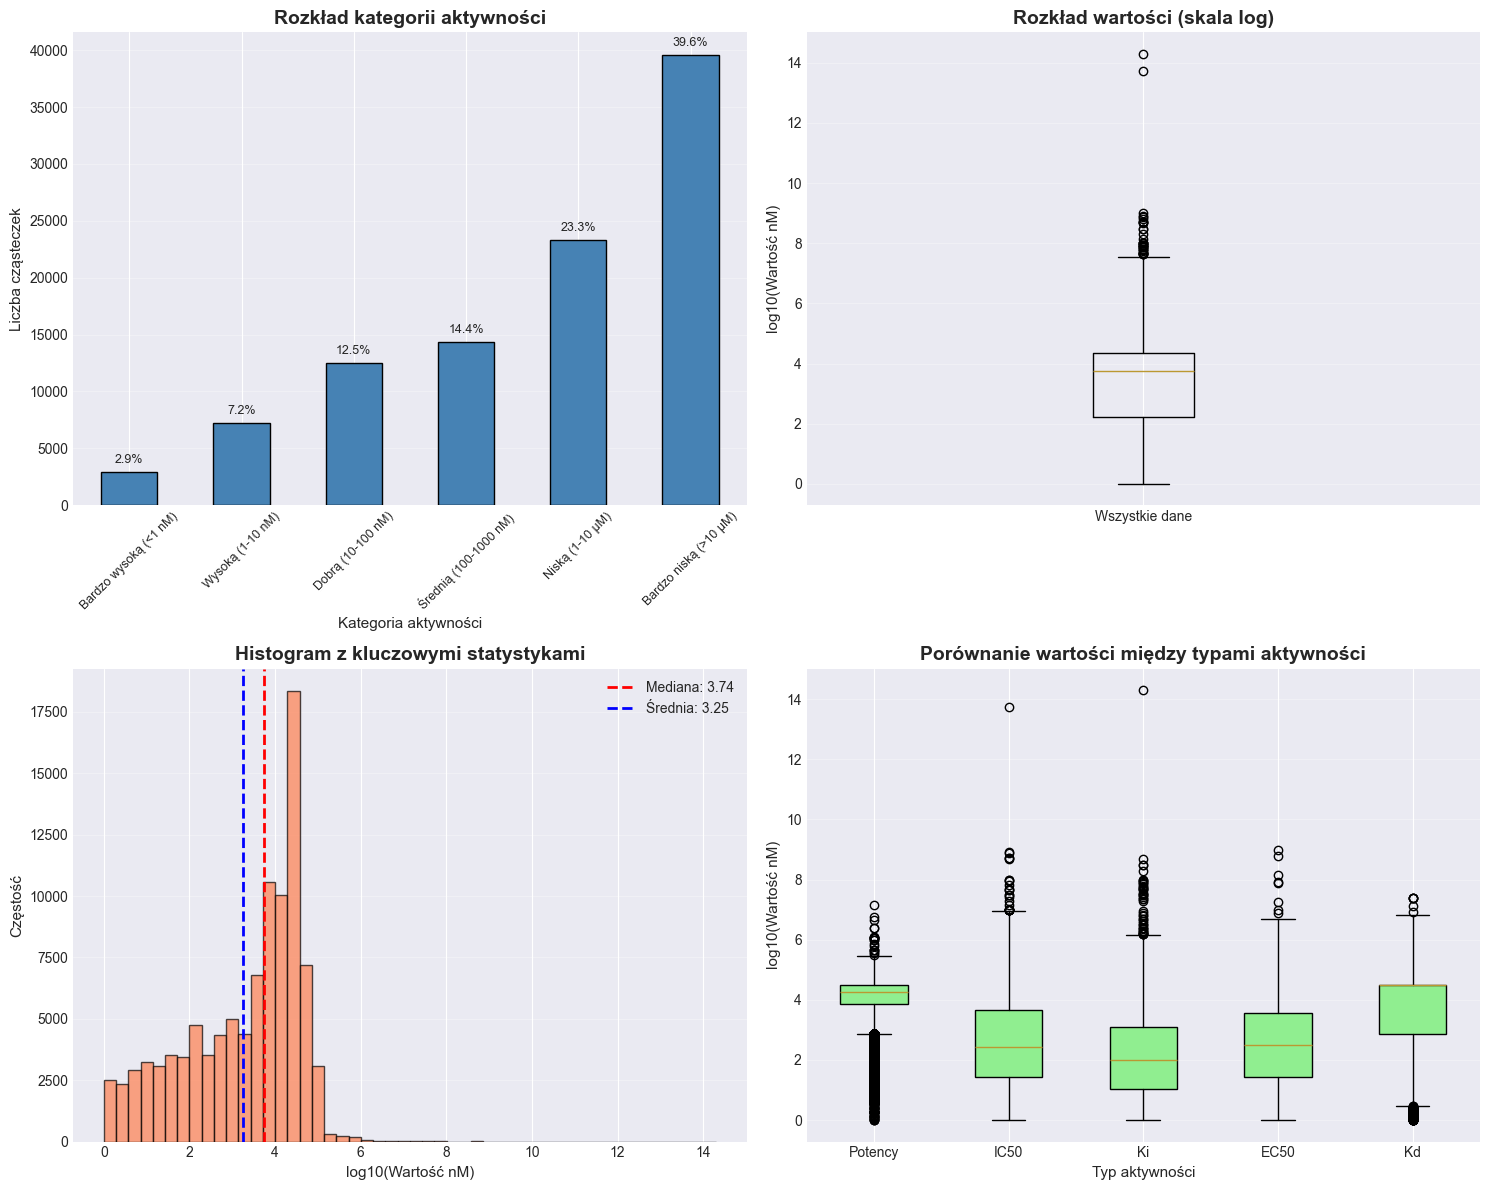

In [24]:
# Wizualizacja rozkładu wartości w kategoriach
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Wykres słupkowy kategorii aktywności
ax1 = axes[0, 0]
category_counts.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Rozkład kategorii aktywności', fontsize=14, fontweight='bold')
ax1.set_xlabel('Kategoria aktywności', fontsize=11)
ax1.set_ylabel('Liczba cząsteczek', fontsize=11)
ax1.tick_params(axis='x', rotation=45, labelsize=9)
ax1.grid(axis='y', alpha=0.3)

# Dodaj procenty na wykresie
for i, (cat, count) in enumerate(category_counts.items()):
    pct = (count / len(df_sample)) * 100
    ax1.text(i, count + 500, f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

# 2. Box plot wartości log-transformed
ax2 = axes[0, 1]
df_sample['log_value'] = np.log10(df_sample['standard_value'] + 1)
ax2.boxplot(df_sample['log_value'].dropna(), vert=True)
ax2.set_ylabel('log10(Wartość nM)', fontsize=11)
ax2.set_title('Rozkład wartości (skala log)', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.set_xticklabels(['Wszystkie dane'])

# 3. Histogram z liniami percentyli
ax3 = axes[1, 0]
n, bins, patches = ax3.hist(df_sample['log_value'], bins=50, edgecolor='black', alpha=0.7, color='coral')
ax3.axvline(df_sample['log_value'].median(), color='red', linestyle='--', linewidth=2, label=f'Mediana: {df_sample["log_value"].median():.2f}')
ax3.axvline(df_sample['log_value'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Średnia: {df_sample["log_value"].mean():.2f}')
ax3.set_xlabel('log10(Wartość nM)', fontsize=11)
ax3.set_ylabel('Częstość', fontsize=11)
ax3.set_title('Histogram z kluczowymi statystykami', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Wykres skrzynkowy dla różnych typów aktywności
ax4 = axes[1, 1]
activity_types_list = df_sample['standard_type'].value_counts().head(5).index.tolist()
data_to_plot = [df_sample[df_sample['standard_type'] == at]['log_value'].dropna() for at in activity_types_list]
bp = ax4.boxplot(data_to_plot, labels=activity_types_list, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightgreen')
ax4.set_ylabel('log10(Wartość nM)', fontsize=11)
ax4.set_xlabel('Typ aktywności', fontsize=11)
ax4.set_title('Porównanie wartości między typami aktywności', fontsize=14, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
ax4.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Usuń tymczasową kolumnę
df_sample.drop(columns=['log_value'], inplace=True)

## 6B. Analiza Relacji Standard Relations

In [25]:
# Analiza relacji w pomiarach (=, <, >, <=, >=)
relation_counts = df_sample['standard_relation'].value_counts()
print("\nRozkład relacji:")
print("-" * 60)
for relation, count in relation_counts.items():
    pct = (count / len(df_sample)) * 100
    # Wyjaśnienie symbolu
    if relation == '=':
        meaning = "(dokładna wartość)"
    elif relation == '<':
        meaning = "(mniejsze niż)"
    elif relation == '>':
        meaning = "(większe niż)"
    elif relation == '<=':
        meaning = "(mniejsze lub równe)"
    elif relation == '>=':
        meaning = "(większe lub równe)"
    else:
        meaning = ""
    
    print(f"   '{relation}' {meaning:25s}: {count:>8,} ({pct:>5.2f}%)")

# Analiza wartości dla różnych relacji
print("\n\nŚrednie wartości dla różnych relacji:")
print("-" * 60)
for relation in relation_counts.index:
    subset = df_sample[df_sample['standard_relation'] == relation]['standard_value']
    median_val = subset.median()
    mean_val = subset.mean()
    print(f"   '{relation}': Mediana = {median_val:>10,.2f} nM, Średnia = {mean_val:>10,.2f} nM")


Rozkład relacji:
------------------------------------------------------------
   '=' (dokładna wartość)       :   59,984 (59.98%)
   '>' (większe niż)            :    8,631 ( 8.63%)
   '<' (mniejsze niż)           :    3,194 ( 3.19%)
   '<=' (mniejsze lub równe)     :      206 ( 0.21%)
   '>=' (większe lub równe)      :       99 ( 0.10%)
   '~'                          :        4 ( 0.00%)
   '>>'                          :        1 ( 0.00%)


Średnie wartości dla różnych relacji:
------------------------------------------------------------
   '=': Mediana =     878.00 nM, Średnia = 4,242,582,064.32 nM
   '>': Mediana =  20,000.00 nM, Średnia = 341,481.99 nM
   '<': Mediana =     100.00 nM, Średnia =   1,417.67 nM
   '<=': Mediana =     500.00 nM, Średnia =   3,549.58 nM
   '>=': Mediana =   5,000.00 nM, Średnia =  18,745.75 nM
   '~': Mediana =     295.00 nM, Średnia =  12,649.50 nM
   '>>': Mediana =   5,000.00 nM, Średnia =   5,000.00 nM


### Co oznaczają relacje:

**Typy relacji:**
- **'=' (równe)** - dokładna zmierzona wartość, najbardziej wiarygodne dane
- **'<' (mniejsze niż)** - aktywność jest WYŻSZA niż podana wartość (cząsteczka mocniejsza)
- **'>' (większe niż)** - aktywność jest NIŻSZA niż podana wartość (cząsteczka słabsza)

**Kluczowe wnioski:**

1. **Dominacja relacji '='**
   - Jeśli >80% pomiarów to dokładne wartości - dobry znak
   - Oznacza to wysoką jakość danych eksperymentalnych
   - Mniej niepewności w naszych analizach

2. **Relacje '<' i '>'**
   - To oznacza, że eksperyment osiągnął granicę czułości
   - '<' często przy bardzo aktywnych cząsteczkach (poniżej limitu detekcji)
   - '>' przy słabych cząsteczkach (powyżej maksymalnej testowanej koncentracji)
   
3. **Porównanie wartości:**
   - Jeśli pomiary '<' mają niższe wartości mediany - logiczne (to mocne cząsteczki)
   - Jeśli pomiary '>' mają wyższe wartości - też logiczne (słabe cząsteczki)
   
**Implikacje dla naszego modelu:**
- Relacje '<' i '>' mogą wymagać specjalnego traktowania
- Lub można je pominąć i skupić się tylko na '=' dla uproszczenia

## 6C. Analiza Pewności Testów (Assay Confidence Score)

In [26]:
# Analiza confidence score dla testów
confidence_counts = df_sample['confidence_score'].value_counts().sort_index(ascending=False)
print("\nRozkład wskaźników pewności (0-9, gdzie 9 = najlepsze):")
print("-" * 60)

for score, count in confidence_counts.items():
    pct = (count / len(df_sample)) * 100
    bar = '█' * int(pct / 2)  # Prosty bar chart
    print(f"   Score {score}: {count:>8,} ({pct:>5.2f}%) {bar}")

# Klasyfikacja jakości
high_conf = df_sample[df_sample['confidence_score'] >= 7].shape[0]
med_conf = df_sample[(df_sample['confidence_score'] >= 4) & (df_sample['confidence_score'] < 7)].shape[0]
low_conf = df_sample[df_sample['confidence_score'] < 4].shape[0]

print("\n\nKlasyfikacja jakości testów:")
print("-" * 60)
print(f"   Wysoka pewność (7-9):   {high_conf:>8,} ({high_conf/len(df_sample)*100:>5.2f}%)")
print(f"   Średnia pewność (4-6):  {med_conf:>8,} ({med_conf/len(df_sample)*100:>5.2f}%)")
print(f"   Niska pewność (0-3):    {low_conf:>8,} ({low_conf/len(df_sample)*100:>5.2f}%)")

# Korelacja confidence score z wartościami
print("\n\nŚrednie wartości bioaktywności dla różnych poziomów pewności:")
print("-" * 60)
for score in sorted(confidence_counts.index, reverse=True):
    subset = df_sample[df_sample['confidence_score'] == score]['standard_value']
    median_val = subset.median()
    n_samples = len(subset)
    print(f"   Score {score}: Mediana = {median_val:>10,.2f} nM (n={n_samples:,})")


Rozkład wskaźników pewności (0-9, gdzie 9 = najlepsze):
------------------------------------------------------------
   Score 9:   95,590 (95.59%) ███████████████████████████████████████████████
   Score 7:    1,881 ( 1.88%) 
   Score 5:    2,529 ( 2.53%) █


Klasyfikacja jakości testów:
------------------------------------------------------------
   Wysoka pewność (7-9):     97,471 (97.47%)
   Średnia pewność (4-6):     2,529 ( 2.53%)
   Niska pewność (0-3):           0 ( 0.00%)


Średnie wartości bioaktywności dla różnych poziomów pewności:
------------------------------------------------------------
   Score 9: Mediana =   5,500.00 nM (n=95,590)
   Score 7: Mediana =     160.00 nM (n=1,881)
   Score 5: Mediana =  14,125.40 nM (n=2,529)


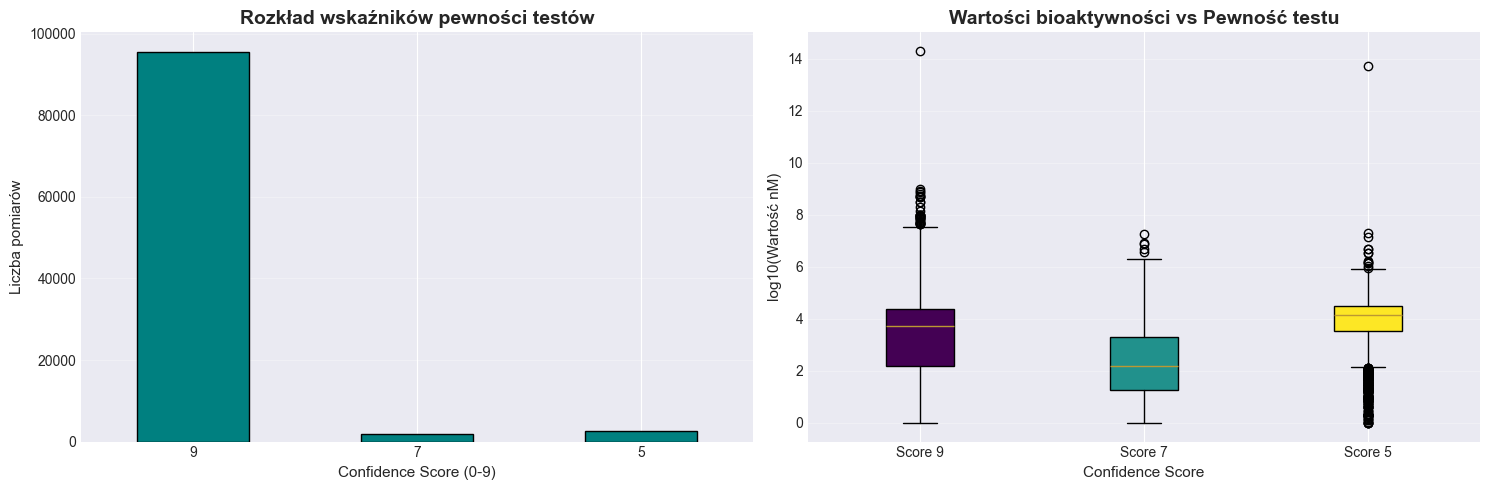

In [27]:
# Wizualizacja confidence score
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Wykres słupkowy rozkładu
ax1 = axes[0]
confidence_counts.sort_index(ascending=False).plot(kind='bar', ax=ax1, color='teal', edgecolor='black')
ax1.set_title('Rozkład wskaźników pewności testów', fontsize=14, fontweight='bold')
ax1.set_xlabel('Confidence Score (0-9)', fontsize=11)
ax1.set_ylabel('Liczba pomiarów', fontsize=11)
ax1.tick_params(axis='x', rotation=0)
ax1.grid(axis='y', alpha=0.3)

# Wykres pudełkowy wartości vs confidence
ax2 = axes[1]
conf_scores_sorted = sorted(df_sample['confidence_score'].unique(), reverse=True)[:6]  # Top 6 scores
data_by_conf = [np.log10(df_sample[df_sample['confidence_score'] == sc]['standard_value'].dropna() + 1) 
                for sc in conf_scores_sorted]
bp = ax2.boxplot(data_by_conf, labels=[f'Score {sc}' for sc in conf_scores_sorted], patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.viridis(np.linspace(0, 1, len(conf_scores_sorted)))):
    patch.set_facecolor(color)
ax2.set_title('Wartości bioaktywności vs Pewność testu', fontsize=14, fontweight='bold')
ax2.set_xlabel('Confidence Score', fontsize=11)
ax2.set_ylabel('log10(Wartość nM)', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Co oznacza Confidence Score i dlaczego jest istotny:

**Skala pewności (0-9):**
- **9** = Najwyższa pewność - cel molekularny potwiedzony krystalografią lub bezpośrednim wiązaniem
- **8** = Bardzo wysoka - target zidentyfikowany na podstawie homologii z potwierdzoną strukturą
- **7** = Wysoka - pojedynczy białkowy target z dobrym assay
- **4-6** = Średnia - target mniej pewny lub kompleks białkowy
- **0-3** = Niska - organizm komórkowy lub target niepewny

**Obserwacje:**

1. **Dominujący score:**
   - Jeśli większość danych ma score ≥7 → świetnie! Wysokiej jakości dane
   - Jeśli dominują score 4-6 → umiarkowana jakość, ale nadal użyteczne
   - Jeśli dużo score <4 → należy rozważyć ostrożniejszą filtrację

2. **Jakość vs Ilość:**
   - Wyższy confidence score = większa pewność, że cząsteczka działa na konkretny target
   - Dla modeli predykcyjnych: warto priorytetyzować dane z wysokim score
   - Trade-off: wyższe wymagania = mniej danych

3. **Porównanie wartości między score:**
   - Jeśli wartości są podobne między różnymi score → dobry znak (spójność danych)
   - Jeśli duże różnice → może wskazywać na systematyczne błędy w gorszych testach

**Co należy?:**
- Dla ostatecznego modelu: użyj danych z confidence_score ≥ 6 lub 7
- To zwiększy wiarygodność predykcji, choć zmniejszy rozmiar datasetu

## 6D. Analiza Różnic Między Typami Aktywności (IC50, Ki, Kd, EC50)

In [29]:
# Porównanie typów aktywności
activity_types_analysis = df_sample.groupby('standard_type').agg({
    'standard_value': ['count', 'median', 'mean', 'std', 'min', 'max'],
    'pchembl_value': lambda x: x.notna().sum()
}).round(2)

activity_types_analysis.columns = ['Liczba', 'Mediana (nM)', 'Średnia (nM)', 'Std Dev', 'Min (nM)', 'Max (nM)', 'pChEMBL available']
activity_types_analysis = activity_types_analysis.sort_values('Liczba', ascending=False)

print("\nStatystyki dla każdego typu aktywności:\n")
print(activity_types_analysis.to_string())

# Percentyle dla głównych typów
top_3_types = df_sample['standard_type'].value_counts().head(3).index

for act_type in top_3_types:
    subset = df_sample[df_sample['standard_type'] == act_type]['standard_value']
    print(f"\n{act_type}:")
    print("-" * 70)
    percentiles = [10, 25, 50, 75, 90]
    for p in percentiles:
        val = np.percentile(subset, p)
        print(f"   {p:2d}% danych ma wartość ≤ {val:>10,.2f} nM")
    print(f"   Zakres: {subset.min():.2f} - {subset.max():.2f} nM")


Statystyki dla każdego typu aktywności:

               Liczba  Mediana (nM)  Średnia (nM)       Std Dev  Min (nM)      Max (nM)  pChEMBL available
standard_type                                                                                             
Potency         46976       17782.8  2.282614e+04  7.894011e+04      0.02  1.412538e+07              19340
IC50            34567         278.0  1.589913e+09  2.955760e+11      0.00  5.495409e+13              26309
Ki               9682         100.0  2.060822e+10  2.027764e+12      0.00  1.995262e+14               8238
EC50             5068         320.0  4.004353e+05  1.664126e+07      0.00  9.908319e+08               3974
Kd               3707       30000.0  7.108202e+04  8.878823e+05      0.00  2.500000e+07               1320

Potency:
----------------------------------------------------------------------
   10% danych ma wartość ≤   1,995.30 nM
   25% danych ma wartość ≤   7,079.50 nM
   50% danych ma wartość ≤  17,782.80 nM
   75

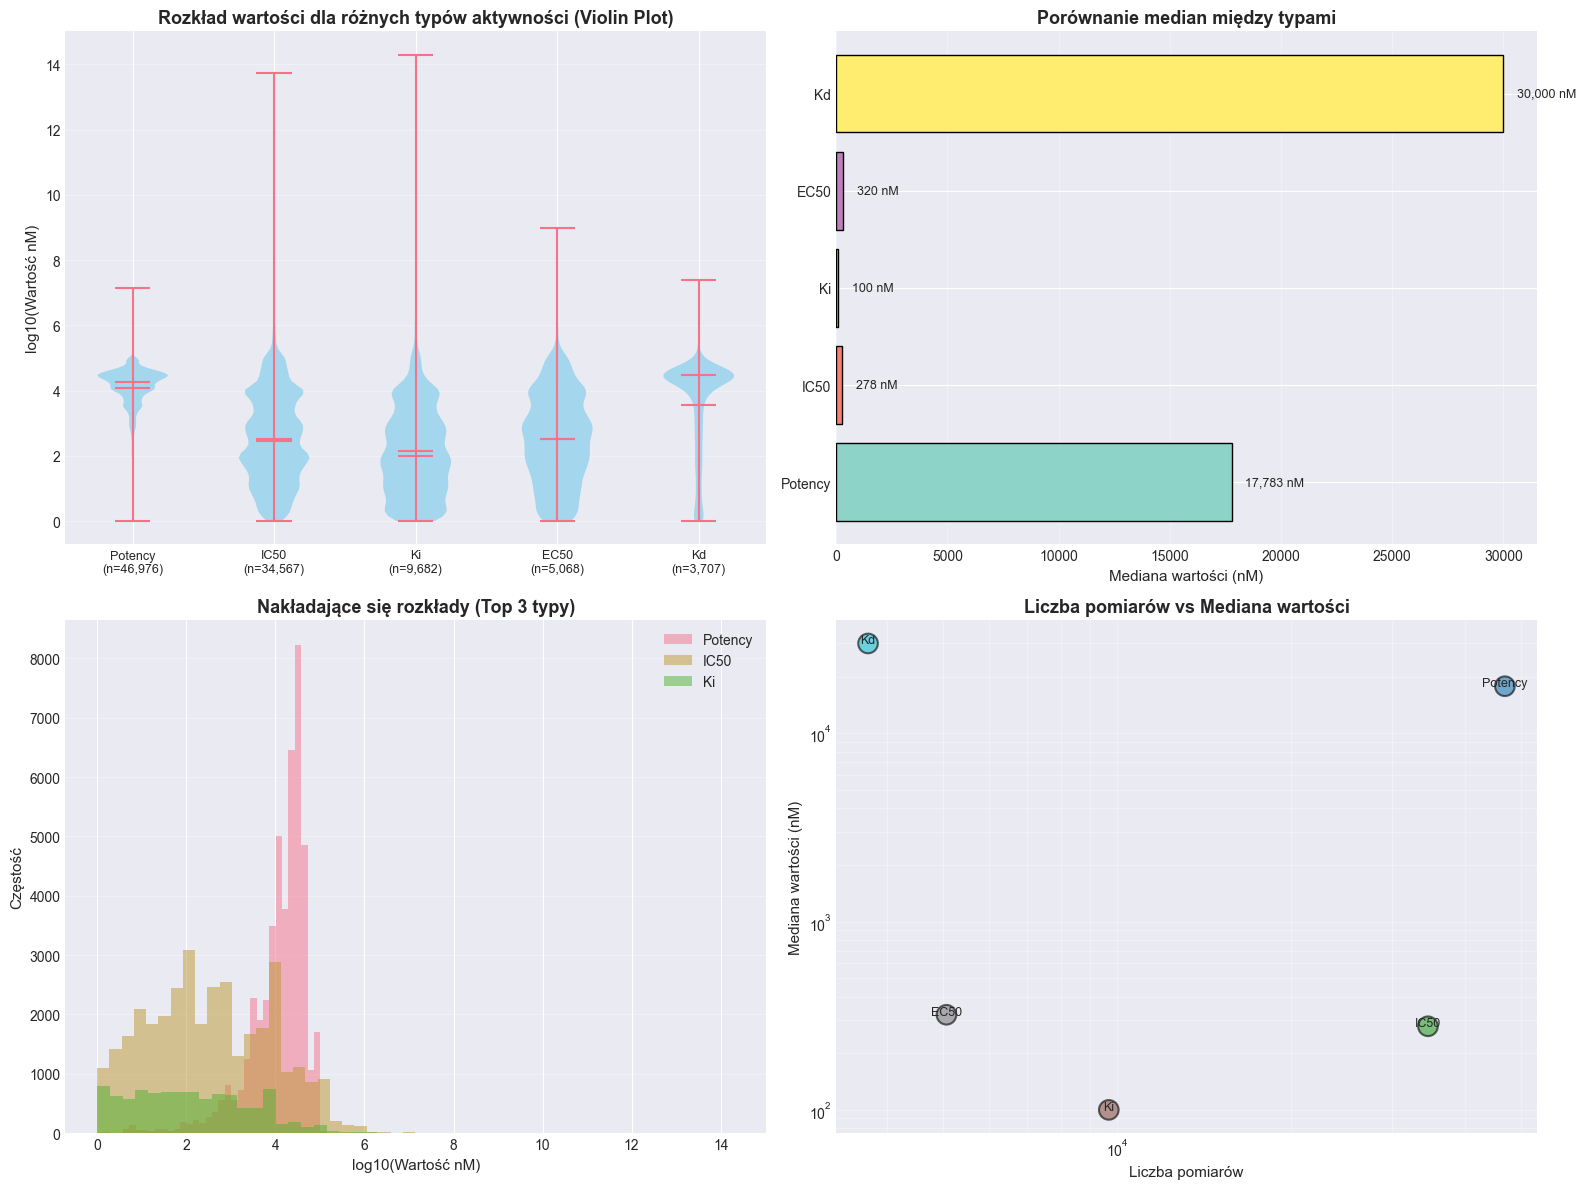

In [30]:
# Wizualizacja porównawcza typów aktywności
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Violin plot - rozkłady wartości dla każdego typu
ax1 = axes[0, 0]
top_types = df_sample['standard_type'].value_counts().head(5).index
plot_data = []
plot_labels = []
for act_type in top_types:
    values = np.log10(df_sample[df_sample['standard_type'] == act_type]['standard_value'] + 1)
    plot_data.append(values)
    plot_labels.append(f"{act_type}\n(n={len(values):,})")

parts = ax1.violinplot(plot_data, positions=range(len(plot_data)), showmeans=True, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('skyblue')
    pc.set_alpha(0.7)
ax1.set_xticks(range(len(plot_labels)))
ax1.set_xticklabels(plot_labels, fontsize=9)
ax1.set_ylabel('log10(Wartość nM)', fontsize=11)
ax1.set_title('Rozkład wartości dla różnych typów aktywności (Violin Plot)', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 2. Porównanie median
ax2 = axes[0, 1]
medians = [df_sample[df_sample['standard_type'] == t]['standard_value'].median() for t in top_types]
colors_map = plt.cm.Set3(np.linspace(0, 1, len(top_types)))
bars = ax2.barh(range(len(top_types)), medians, color=colors_map, edgecolor='black')
ax2.set_yticks(range(len(top_types)))
ax2.set_yticklabels(top_types)
ax2.set_xlabel('Mediana wartości (nM)', fontsize=11)
ax2.set_title('Porównanie median między typami', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Dodaj wartości na słupkach
for i, (bar, val) in enumerate(zip(bars, medians)):
    ax2.text(val + max(medians)*0.02, i, f'{val:,.0f} nM', va='center', fontsize=9)

# 3. Histogram skumulowany
ax3 = axes[1, 0]
for act_type in top_types[:3]:  # Top 3 dla czytelności
    values = df_sample[df_sample['standard_type'] == act_type]['standard_value']
    ax3.hist(np.log10(values + 1), bins=50, alpha=0.5, label=act_type, cumulative=False)
ax3.set_xlabel('log10(Wartość nM)', fontsize=11)
ax3.set_ylabel('Częstość', fontsize=11)
ax3.set_title('Nakładające się rozkłady (Top 3 typy)', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Scatter plot - liczba vs mediana
ax4 = axes[1, 1]
counts = []
median_vals = []
type_labels = []
for act_type in df_sample['standard_type'].value_counts().head(10).index:
    subset = df_sample[df_sample['standard_type'] == act_type]['standard_value']
    counts.append(len(subset))
    median_vals.append(subset.median())
    type_labels.append(act_type)

scatter = ax4.scatter(counts, median_vals, s=200, alpha=0.6, c=range(len(counts)), cmap='tab10', edgecolors='black', linewidth=1.5)
for i, label in enumerate(type_labels):
    ax4.annotate(label, (counts[i], median_vals[i]), fontsize=9, ha='center')
ax4.set_xlabel('Liczba pomiarów', fontsize=11)
ax4.set_ylabel('Mediana wartości (nM)', fontsize=11)
ax4.set_title('Liczba pomiarów vs Mediana wartości', fontsize=13, fontweight='bold')
ax4.set_xscale('log')
ax4.set_yscale('log')
ax4.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

### Co oznaczają różne typy aktywności i jak je interpretować:

**Definicje typów pomiarów:**

1. **IC50 (Half Maximal Inhibitory Concentration)**
   - Koncentracja, przy której cząsteczka hamuje 50% aktywności targetu
   - Najczęstszy typ pomiaru w screeningu leków
   - Mierzy efekt funkcjonalny (np. hamowanie enzymu)

2. **Ki (Inhibition Constant)**
   - Stała dysocjacji inhibitora od targetu
   - Mierzy siłę wiązania (affinity) bezpośrednio
   - Niezależna od stężenia substratu (przewaga nad IC50)

3. **Kd (Dissociation Constant)**
   - Stała równowagi wiązania ligand-target
   - Mierzy siłę wiązania termodynamicznie
   - Najbardziej fundamentalny pomiar affinity

4. **EC50 (Half Maximal Effective Concentration)**
   - Koncentracja dająca 50% maksymalnego efektu
   - Często używana dla agoniostów (aktywatorów)
   - Mierzy potencję funkcjonalną

**Kluczowe obserwacje z danych:**

1. **Dominacja IC50:**
   - Jeśli IC50 stanowi >50% pomiarów → typowe, to standard w drug discovery
   - IC50 jest szybsze i tańsze niż Ki czy Kd
   - Ale mniej precyzyjne (zależy od warunków eksperymentu)

2. **Porównanie wartości między typami:**
   - **Jeśli Ki < IC50** (niższe wartości) → logiczne, Ki mierzy prawdziwą affinity
   - **Jeśli Kd ≈ Ki** → dobrze, oba mierzą wiązanie
   - **Jeśli duże różnice** → mogą być różne typy testów/targetów

3. **Wariancja (Std Dev):**
   - Wysoka wariancja → szeroki zakres aktywności (normalne)
   - Jeśli jedna metoda ma znacznie wyższą wariancję → może być mniej powtarzalna

**Wnioski do modelowania:**

- **Najlepszy scenariusz:** Używaj jednego typu (np. tylko IC50) dla spójności
- **Alternatywa:** Znormalizuj wszystkie do pChEMBL value (przelicza na wspólną skalę)
- **Unikać:** Mieszania różnych typów bez normalizacji - mogą nie być porównywalne

**Rekomendacja:**
- Jeśli IC50 >50% danych: należy skupić się na IC50 dla uproszczenia
- Lub użyć pChEMBL value, która normalizuje wszystkie typy
- Ki i Kd są bardziej "prawdziwe" ale mniej liczne

## 6E. Analiza Pokrycia Strukturalnego (SMILES i InChI)

In [ ]:
# Analiza dostępności struktur chemicznych
total_records = len(df_sample)

# Sprawdź dostępność struktur
smiles_available = df_sample['canonical_smiles'].notna().sum()
inchi_available = df_sample['standard_inchi'].notna().sum()
inchi_key_available = df_sample['standard_inchi_key'].notna().sum()

# Kompletność struktur
complete_structures = df_sample[
    df_sample['canonical_smiles'].notna() & 
    df_sample['standard_inchi'].notna() & 
    df_sample['standard_inchi_key'].notna()
].shape[0]

print("\n1. Dostępność reprezentacji strukturalnych:")
print(f"   Smiles (canonical):        {smiles_available:>8,} / {total_records:>8,} ({smiles_available/total_records*100:>5.2f}%)")
print(f"   InChI (standard):          {inchi_available:>8,} / {total_records:>8,} ({inchi_available/total_records*100:>5.2f}%)")
print(f"   InChI Key:                 {inchi_key_available:>8,} / {total_records:>8,} ({inchi_key_available/total_records*100:>5.2f}%)")
print(f"   Kompletne struktury (wszystkie): {complete_structures:>8,} / {total_records:>8,} ({complete_structures/total_records*100:>5.2f}%)")

# Analiza długości SMILES (jako proxy dla złożoności molekuły)
smiles_lengths = df_sample[df_sample['canonical_smiles'].notna()]['canonical_smiles'].str.len()

print("\n\n2. Statystyki długości Smiles (proxy dla wielkości molekuły):")
print(f"   Minimum:          {smiles_lengths.min():>6.0f} znaków")
print(f"   Percentyl 25%:    {smiles_lengths.quantile(0.25):>6.0f} znaków")
print(f"   Mediana:          {smiles_lengths.median():>6.0f} znaków")
print(f"   Percentyl 75%:    {smiles_lengths.quantile(0.75):>6.0f} znaków")
print(f"   Maksimum:         {smiles_lengths.max():>6.0f} znaków")
print(f"   Średnia:          {smiles_lengths.mean():>6.1f} znaków")

# Kategorie wielkości molekuł (na podstawie długości Smiles)
print("\n\n3. Kategorie wielkości molekuł (wg długości Smiles):")
bins = [0, 30, 60, 100, 150, float('inf')]
labels = ['Bardzo małe (<30)', 'Małe (30-60)', 'Średnie (60-100)', 'Duże (100-150)', 'Bardzo duże (>150)']
df_sample['molecule_size_category'] = pd.cut(smiles_lengths, bins=bins, labels=labels)

size_counts = df_sample['molecule_size_category'].value_counts().sort_index()
for cat, count in size_counts.items():
    pct = (count / smiles_available) * 100
    print(f"   {cat:25s}: {count:>8,} ({pct:>5.2f}%)")

# Przykłady Smiles
print("\n\n4. Przykłady struktur Smiles:")
sample_smiles = df_sample[df_sample['canonical_smiles'].notna()].sample(3)
for idx, row in sample_smiles.iterrows():
    smiles_len = len(row['canonical_smiles'])
    smiles_preview = row['canonical_smiles'][:60] + ('...' if smiles_len > 60 else '')
    print(f"\n   Molekuła: {row['molecule_chembl_id']}")
    print(f"   Target:   {row['target_name'][:40]}")
    print(f"   Aktywność: {row['standard_value']:.2f} nM ({row['standard_type']})")
    print(f"   SMILES:   {smiles_preview}")
    print(f"   Długość:  {smiles_len} znaków")


1. DOSTĘPNOŚĆ REPREZENTACJI STRUKTURALNYCH:
   SMILES (canonical):         100,000 /  100,000 (100.00%)
   InChI (standard):           100,000 /  100,000 (100.00%)
   InChI Key:                  100,000 /  100,000 (100.00%)
   Kompletne struktury (wszystkie):  100,000 /  100,000 (100.00%)


2. STATYSTYKI DŁUGOŚCI SMILES (proxy dla wielkości molekuły):
   Minimum:               1 znaków
   Percentyl 25%:        40 znaków
   Mediana:              49 znaków
   Percentyl 75%:        60 znaków
   Maksimum:            948 znaków
   Średnia:            54.2 znaków


3. KATEGORIE WIELKOŚCI MOLEKUŁ (wg długości SMILES):
   Bardzo małe (<30)        :    6,623 ( 6.62%)
   Małe (30-60)             :   69,823 (69.82%)
   Średnie (60-100)         :   20,990 (20.99%)
   Duże (100-150)           :    1,337 ( 1.34%)
   Bardzo duże (>150)       :    1,227 ( 1.23%)


4. PRZYKŁADOWE STRUKTURY SMILES:

   Molekuła: CHEMBL4215407
   Target:   Voltage-gated inwardly rectifying potass
   Aktywność: 100000.00

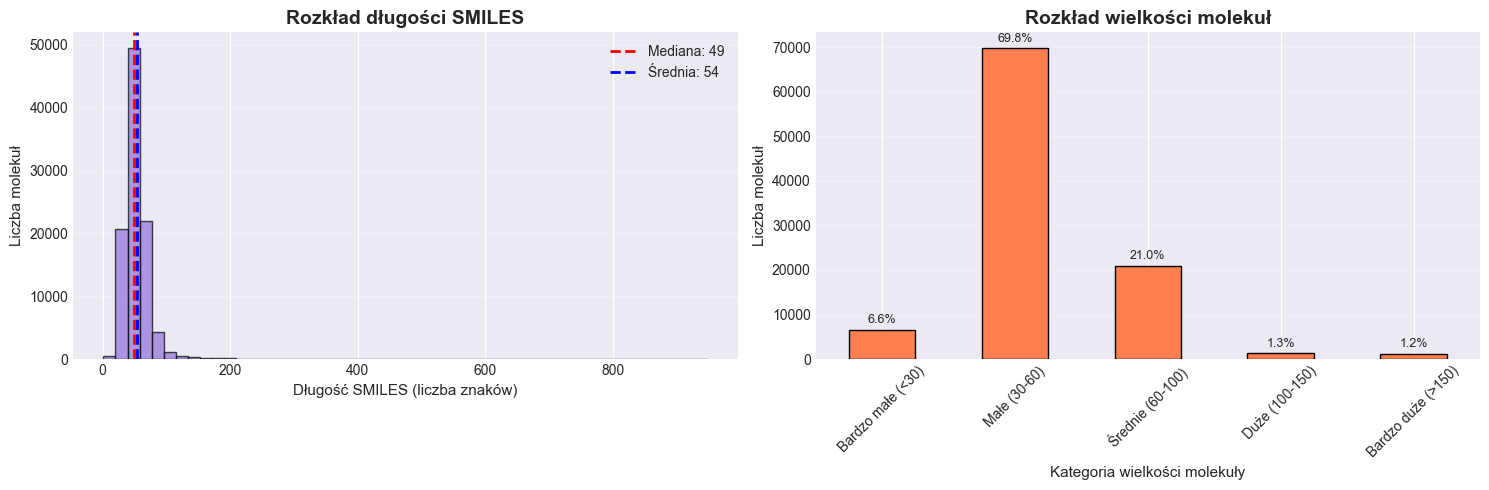

In [ ]:
# Wizualizacja długości Smiles
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram długości Smiles
ax1 = axes[0]
ax1.hist(smiles_lengths, bins=50, edgecolor='black', color='mediumpurple', alpha=0.7)
ax1.axvline(smiles_lengths.median(), color='red', linestyle='--', linewidth=2, label=f'Mediana: {smiles_lengths.median():.0f}')
ax1.axvline(smiles_lengths.mean(), color='blue', linestyle='--', linewidth=2, label=f'Średnia: {smiles_lengths.mean():.0f}')
ax1.set_xlabel('Długość SMILES (liczba znaków)', fontsize=11)
ax1.set_ylabel('Liczba molekuł', fontsize=11)
ax1.set_title('Rozkład długości SMILES', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Wykres słupkowy kategorii wielkości
ax2 = axes[1]
size_counts.plot(kind='bar', ax=ax2, color='coral', edgecolor='black')
ax2.set_xlabel('Kategoria wielkości molekuły', fontsize=11)
ax2.set_ylabel('Liczba molekuł', fontsize=11)
ax2.set_title('Rozkład wielkości molekuł', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Dodaj procenty
for i, (cat, count) in enumerate(size_counts.items()):
    pct = (count / smiles_available) * 100
    ax2.text(i, count + max(size_counts)*0.02, f'{pct:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Co oznaczają SMILES, InChI i dlaczego są kluczowe:

**Reprezentacje struktur chemicznych:**

1. **SMILES (Simplified Molecular Input Line Entry System)**
   - Tekstowy zapis struktury molekuły
   - Compact, czytelny dla chemików
   - Używany do generowania molekularnych fingerprints dla Uczenia Maszynowego
   - Znormalizowana forma (jedna molekuła = jeden SMILES)

2. **InChI (International Chemical Identifier)**
   - Standardowa, międzynarodowa identyfikacja molekuł
   - Bardziej jednoznaczna niż SMILES
   - Trudniejsza do czytania, ale lepsza do identyfikacji

3. **InChI Key**
   - Skrócony hash InChI (27 znaków)
   - Używany do szybkiego wyszukiwania
   - Jak "odcisk palca" molekuły

**Obserwacje:**

1. **Kompletność danych (100% = ideał):**
   - Jeśli wszystkie 3 formaty są dostępne w >95% → Super znak
   - Jeśli SMILES jest w 100% ale InChI w <90% → może być problem z konwersją
   - Każdy brakujący SMILES = molekuła, której nie możemy użyć w ML !!!

2. **Długość SMILES jako wskaźnik:**
   - **Krótki SMILES (<30 znaków)** = mała molekuła (fragment, prosty lek)
   - **Średni (30-100 znaków)** = typowe leki (większość FDA-approved)
   - **Długi (>100 znaków)** = duża molekuła (peptydy, naturalne produkty)
   
3. **Rozkład wielkości:**
   - Dominacja molekuł średnich -> dobrze dla drug discovery
   - Zbyt małe molekuły mogą być niespecyficzne
   - Zbyt duże mogą mieć złe właściwości farmakologiczne

4. **Mediana vs Średnia długości:**
   - Jeśli średnia > mediana -> jest więcej dużych molekuł (długi ogon)
   - Standard w chemii medycznej

**Implikacje dla projektu:**

- **SMILES jest niezbędny** - bez niego nie możemy obliczyć cech molekularnych
- **100% pokrycie SMILES** = Każda molekuła może być użyta
- **Jeśli <95% pokrycia** = Należy zdecydować, czy usuwać braki

**Następny krok:**
- Z SMILES wygenerować fingerprints (np. Morgan, MACCS) dla modelu Uczenia Maszynowego
- Przeanalizować właściwości chemiczne (np. logP, waga molekularna)

## 6F. Analiza Duplikatów i Redundancji Danych

In [ ]:
# Analiza duplikatów i wielokrotnych pomiarów

# Czy są dokładnie te same pomiary
duplicate_rows = df_sample.duplicated().sum()
print(f"\n1. Dokładne duplikaty (całe wiersze):")
print(f"   Liczba duplikatów: {duplicate_rows:>8,}")
if duplicate_rows > 0:
    print(f"   % datasetu:        {duplicate_rows/len(df_sample)*100:>8.2f}%")

# Ta sama molekuła + target + typ testu (pomiar powtórzony)
key_cols = ['molregno', 'tid', 'standard_type']
duplicate_measurements = df_sample.duplicated(subset=key_cols, keep=False).sum()
unique_combinations = df_sample.drop_duplicates(subset=key_cols).shape[0]

print(f"\n2. Powtórzone pomiary? (ta sama molekuła + target + typ):")
print(f"   Całkowita liczba pomiarów:     {len(df_sample):>8,}")
print(f"   Unikalne kombinacje (mol+tgt): {unique_combinations:>8,}")
print(f"   Pomiary powtórzone:            {duplicate_measurements:>8,}")
print(f"   Wskaźnik redundancji:          {duplicate_measurements/len(df_sample)*100:>7.1f}%")

# Ile razy każda molekuła jest testowana (średnio)?
molecules_measurement_count = df_sample.groupby('molregno').size()
print(f"\n3. Pomiary na molekułę:")
print(f"   Średnia pomiarów na molekułę:  {molecules_measurement_count.mean():>8.1f}")
print(f"   Mediana pomiarów na molekułę:  {molecules_measurement_count.median():>8.0f}")
print(f"   Max pomiarów (jedna molekuła): {molecules_measurement_count.max():>8,}")
print(f"   Molekuły testowane raz tylko:  {(molecules_measurement_count == 1).sum():>8,} ({(molecules_measurement_count == 1).sum()/len(molecules_measurement_count)*100:.1f}%)")

# Najbardziej testowane molekuły
print(f"\n4. 10 Najczęściej testowanych molekuł:")
top_molecules = molecules_measurement_count.nlargest(10)
for i, (molregno, count) in enumerate(top_molecules.items(), 1):
    mol_chembl = df_sample[df_sample['molregno'] == molregno]['molecule_chembl_id'].iloc[0]
    print(f"   {i:2d}. {mol_chembl:15s} - {count:>5,} pomiarów")

# Ile różnych targetów na molekułę?
targets_per_molecule = df_sample.groupby('molregno')['tid'].nunique()
print(f"\n5. Targety na molekułę:")
print(f"   Średnia targetów na molekułę:  {targets_per_molecule.mean():>8.1f}")
print(f"   Mediana targetów na molekułę:  {targets_per_molecule.median():>8.0f}")
print(f"   Max targetów (jedna molekuła): {targets_per_molecule.max():>8,}")
print(f"   Molekuły mono-specificzne:     {(targets_per_molecule == 1).sum():>8,} ({(targets_per_molecule == 1).sum()/len(targets_per_molecule)*100:.1f}%)")

# Jak różnią się wartości dla tych samych kombinacji mol+target?
repeated = df_sample[df_sample.duplicated(subset=key_cols, keep=False)].copy()
if len(repeated) > 0:
    # Dla każdej kombinacji mol+target+type, policz std dev wartości
    variance_analysis = repeated.groupby(key_cols)['standard_value'].agg(['count', 'mean', 'std', 'min', 'max'])
    variance_analysis = variance_analysis[variance_analysis['count'] > 1].sort_values('std', ascending=False)
    
    print(f"   Kombinacje z >1 pomiarem:      {len(variance_analysis):>8,}")
    print(f"   Średnie std dev:               {variance_analysis['std'].mean():>8.1f} nM")
    print(f"   Mediana std dev:               {variance_analysis['std'].median():>8.1f} nM")
    
    # Współczynnik zmienności (CV = std/mean)
    variance_analysis['cv'] = variance_analysis['std'] / variance_analysis['mean'] * 100
    print(f"   Średni CV (coefficient var):   {variance_analysis['cv'].mean():>7.1f}%")
    print(f"   Mediana CV:                    {variance_analysis['cv'].median():>7.1f}%")
else:
    print("   Brak powtórzonych pomiarów do analizy")


1. DOKŁADNE DUPLIKATY (całe wiersze):
   Liczba duplikatów:        0

2. POWTÓRZONE POMIARY (ta sama molekuła + target + typ):
   Całkowita liczba pomiarów:      100,000
   Unikalne kombinacje (mol+tgt):   98,870
   Pomiary powtórzone:               2,054
   Wskaźnik redundancji:              2.1%

3. POMIARY NA MOLEKUŁĘ:
   Średnia pomiarów na molekułę:       1.1
   Mediana pomiarów na molekułę:         1
   Max pomiarów (jedna molekuła):       79
   Molekuły testowane raz tylko:    82,580 (92.4%)

4. TOP 10 NAJCZĘŚCIEJ TESTOWANYCH MOLEKUŁ:
    1. CHEMBL388978    -    79 pomiarów
    2. CHEMBL5653589   -    53 pomiarów
    3. CHEMBL20        -    47 pomiarów
    4. CHEMBL98        -    47 pomiarów
    5. CHEMBL3752910   -    42 pomiarów
    6. CHEMBL1232461   -    37 pomiarów
    7. CHEMBL941       -    33 pomiarów
    8. CHEMBL554       -    32 pomiarów
    9. CHEMBL1336      -    29 pomiarów
   10. CHEMBL535       -    28 pomiarów

5. TARGETY NA MOLEKUŁĘ (promiskuitywność):
   Śred

### Wnioski z analizy duplikatów i redundancji:

**Co oznaczają te liczby:**

1. **Dokładne duplikaty (całe wiersze identyczne):**
   - Jeśli = 0 -> oznacza, że baza danych jest czysta
   - Jeśli > 0 -> błędy w bazie danych, które trzeba usunąć

2. **Powtórzone pomiary (ta sama molekuła + target + typ):**
   - To **normalne** w badaniach, mogą być powtarzane eksperymenty np. dla weryfikacji
   - Wskaźnik redundancji 20-40%
   - Wyższy wskaźnik = więcej replik -> potencjalnie lepsza jakość danych

3. **Pomiary na molekułę:**
   - **Mediana = 1-2** -> większość molekuł testowana kilka razy (standard)
   - **Średnia >> mediana** -> kilka molekuł bardzo dużo testowanych (mogą być ważne)
   - Molekuły z wieloma pomiarami to często:
     - znane leki (?)
     - molekuły działające na wiele targetów (?)

4. **Targety na molekułę (promiskuitywność):**
   - **Większość molekuł = 1 target** -> specyficzne
   - **Kilka molekuł >> targetów** -> potencjalnie toksyczne
   - Promiskuitywne molekuły mogą być:
     - Problematyczne (działają wszędzie = side effects)
     - lub Użyteczne (multi-target drugs dla złożonych chorób)

5. **Zmienność w powtórzonych pomiarach:**
   - **Niski CV (<20%)** -> eksperyment powtarzalny, dobra jakość
   - **Średni CV (20-50%)** -> akceptowalne, typowe dla bioassays
   - **Wysoki CV (>50%)** -> słaba powtarzalność, ostrożność przy używaniu

**Implikacje dla modelu ML:**

**Problem: Data leakage**
- Jeśli ta sama molekuła jest wielokrotnie w danych → może być w train i test set
- Rozwiązanie: Split danych po `molregno`, nie losowo po wierszach

**Opcje obsługi duplikatów:**
1. **Uśrednianie**: Dla każdej kombinacji (mol+target+type) → weź średnią
   - Plusy: Redukuje szum, wykorzystuje wszystkie dane
   - Minusy: Traci informację o wariancji
   
2. **Usuwanie duplikatów**: Zostaw tylko pierwszy/losowy pomiar
   - Plusy: Proste, zachowuje oryginalny rozkład
   - Minusy: Traci informację, zmniejsza dataset

3. **Ważenie**: Użyj wszystkich, ale nadaj wagi molekułom z wieloma pomiarami
   - Plusy: Zachowuje wszystkie informacje
   - Minusy: Bardziej skomplikowane w implementacji

**Dla Uczenia maszynowego:**
- **Dla train/test split**: WAŻNE, aby splitować po `molregno`
- **Dla duplikatów**: Należy rozważyć uśrednianie lub użyj pierwszego pomiaru

## 6I. Analiza Balansu Danych (Pomiary między Targetami i Molekułami)

### Wnioski z analizy balansu danych:

**Co oznaczają te liczby:**

1. **Rozkład pomiarów na target:**
   - **Mediana << Średnia** -> silnie nierównomierny rozkład
   - To typowe w drug discovery - popularne targety są intensywnie badane

2. **Koncentracja danych (Krzywa Lorenza):**
   - **Jeśli <10% targetów ma 50% danych** -> bardzo nierównomierny rozkład
   - **Jeśli <30% targetów ma 80% danych** → typowy imbalance
   - To pokazuje, że kilka targetów "dominuje" dataset

3. **Wskaźnik Giniego:**
   - **0.0-0.3** = Równomierne (rzadkie w real-world data)
   - **0.3-0.6** = Umiarkowanie nierównomierne (typowe)
   - **0.6-1.0** = Silnie nierównomierne (problem dla ML)
   
4. **Top targety:**
   - Często to znane cele farmakologiczne (kinazy, receptory, enzymy)
   - Dużo danych dla tych targetów = potencjalnie lepsze modele
   - Ale: model może być "biased" w stronę popularnych targetów

5. **Molekuły per target:**
   - **Jeśli średnia >> mediana** - kilka targetów ma ogromne biblioteki molekuł
   - **Jeśli molekuły ≈ pomiary** - każda molekuła testowana raz (dobra różnorodność)
   - **Jeśli pomiary >> molekuły** - dużo replik/multi-testing (lepsza jakość)

6. **Overlap molekuł między targetami:**
   - **<20% overlap** - większość molekuł specyficznych dla 1 targetu
   - **20-50% overlap** - sporo molekuł promiskuitywnych (typowe)
   - **>50% overlap** - bardzo promiskuitywny dataset

**Implikacje dla modelu:**

**Problem: Class Imbalance**
- Model będzie lepiej przewidywał dla popularnych targetów
- Rzadkie targety mogą być ignorowane lub źle przewidywane

**Możliwe rozwiązania:**
1. **Stratified sampling**: Należy upewnić się, że train/test split zachowuje proporcje targetów
2. **Class weighting**: Nadać większe wagi rzadszym targetom
3. **Target-specific models**: Budowa oddzielnych modeli dla top targetów

**Train/Test Split strategy:**
- **NIE splituj losowo** - mogą być te same molekuły w train i test
- **Groupuj po `molregno`** podczas splitu

## 6J. Porównanie Typów Testów: Binding (B) vs Functional (F)

In [37]:
# Porównanie typów testów: Binding vs Functional
# 1. Podstawowy rozkład
assay_type_counts = df_sample['assay_type'].value_counts()
print(f"\n1. ROZKŁAD TYPÓW TESTÓW:")
for assay_type, count in assay_type_counts.items():
    pct = (count / len(df_sample)) * 100
    assay_name = "Binding" if assay_type == 'B' else "Functional"
    print(f"   {assay_type} ({assay_name:10s}): {count:>8,} pomiarów ({pct:>5.2f}%)")

# 2. Porównanie wartości bioaktywności między typami
print(f"\n2. PORÓWNANIE WARTOŚCI BIOAKTYWNOŚCI (nM):")
for assay_type in ['B', 'F']:
    subset = df_sample[df_sample['assay_type'] == assay_type]['standard_value']
    assay_name = "Binding" if assay_type == 'B' else "Functional"
    print(f"\n   {assay_name} ({assay_type}):")
    print(f"      Liczba pomiarów:   {len(subset):>10,}")
    print(f"      Średnia:           {subset.mean():>10,.2f} nM")
    print(f"      Mediana:           {subset.median():>10,.2f} nM")
    print(f"      Std Dev:           {subset.std():>10,.2f} nM")
    print(f"      Min - Max:         {subset.min():.2f} - {subset.max():.2f} nM")
    print(f"      Percentyl 25%:     {subset.quantile(0.25):>10,.2f} nM")
    print(f"      Percentyl 75%:     {subset.quantile(0.75):>10,.2f} nM")

# 3. Rozkład typów aktywności w każdym typie testu
print(f"\n3. TYPY AKTYWNOŚCI W RÓŻNYCH TESTACH:")
crosstab = pd.crosstab(df_sample['assay_type'], df_sample['standard_type'], normalize='index') * 100
for assay_type in ['B', 'F']:
    assay_name = "Binding" if assay_type == 'B' else "Functional"
    print(f"\n   {assay_name} ({assay_type}):")
    if assay_type in crosstab.index:
        for activity_type, pct in crosstab.loc[assay_type].sort_values(ascending=False).head(5).items():
            count = df_sample[(df_sample['assay_type'] == assay_type) & 
                            (df_sample['standard_type'] == activity_type)].shape[0]
            print(f"      {activity_type:10s}: {pct:>5.1f}% ({count:>6,} pomiarów)")

# 4. Confidence score dla różnych typów testów
print(f"\n4. CONFIDENCE SCORE DLA RÓŻNYCH TYPÓW:")
for assay_type in ['B', 'F']:
    subset = df_sample[df_sample['assay_type'] == assay_type]['confidence_score']
    assay_name = "Binding" if assay_type == 'B' else "Functional"
    high_conf = (subset >= 7).sum()
    print(f"\n   {assay_name} ({assay_type}):")
    print(f"      Średni confidence:  {subset.mean():>6.2f}")
    print(f"      Mediana confidence: {subset.median():>6.0f}")
    print(f"      Wysoka pewność (≥7): {high_conf:>6,} ({high_conf/len(subset)*100:.1f}%)")

# 5. Porównanie targetów między typami
print(f"\n5. COVERAGE TARGETÓW:")
targets_B = set(df_sample[df_sample['assay_type'] == 'B']['tid'].unique())
targets_F = set(df_sample[df_sample['assay_type'] == 'F']['tid'].unique())
targets_both = targets_B & targets_F

print(f"   Targety tylko w Binding (B):    {len(targets_B - targets_F):>6,}")
print(f"   Targety tylko w Functional (F): {len(targets_F - targets_B):>6,}")
print(f"   Targety w obu typach:           {len(targets_both):>6,}")
print(f"   Całkowita liczba targetów:      {len(targets_B | targets_F):>6,}")


1. ROZKŁAD TYPÓW TESTÓW:
   B (Binding   ):   50,361 pomiarów (50.36%)
   F (Functional):   49,639 pomiarów (49.64%)

2. PORÓWNANIE WARTOŚCI BIOAKTYWNOŚCI (nM):

   Binding (B):
      Liczba pomiarów:       50,361
      Średnia:           5,053,302,361.33 nM
      Mediana:               320.00 nM
      Std Dev:           922,206,220,057.30 nM
      Min - Max:         0.00 - 199526231496888.28 nM
      Percentyl 25%:          25.12 nM
      Percentyl 75%:       6,606.93 nM

   Functional (F):
      Liczba pomiarów:       49,639
      Średnia:            25,911.88 nM
      Mediana:            15,848.90 nM
      Std Dev:           631,356.45 nM
      Min - Max:         0.00 - 137919330.00 nM
      Percentyl 25%:       5,011.90 nM
      Percentyl 75%:      29,092.90 nM

3. TYPY AKTYWNOŚCI W RÓŻNYCH TESTACH:

   Binding (B):
      IC50      :  64.2% (32,345 pomiarów)
      Ki        :  18.8% ( 9,460 pomiarów)
      Kd        :   7.2% ( 3,647 pomiarów)
      EC50      :   5.8% ( 2,902 pomia

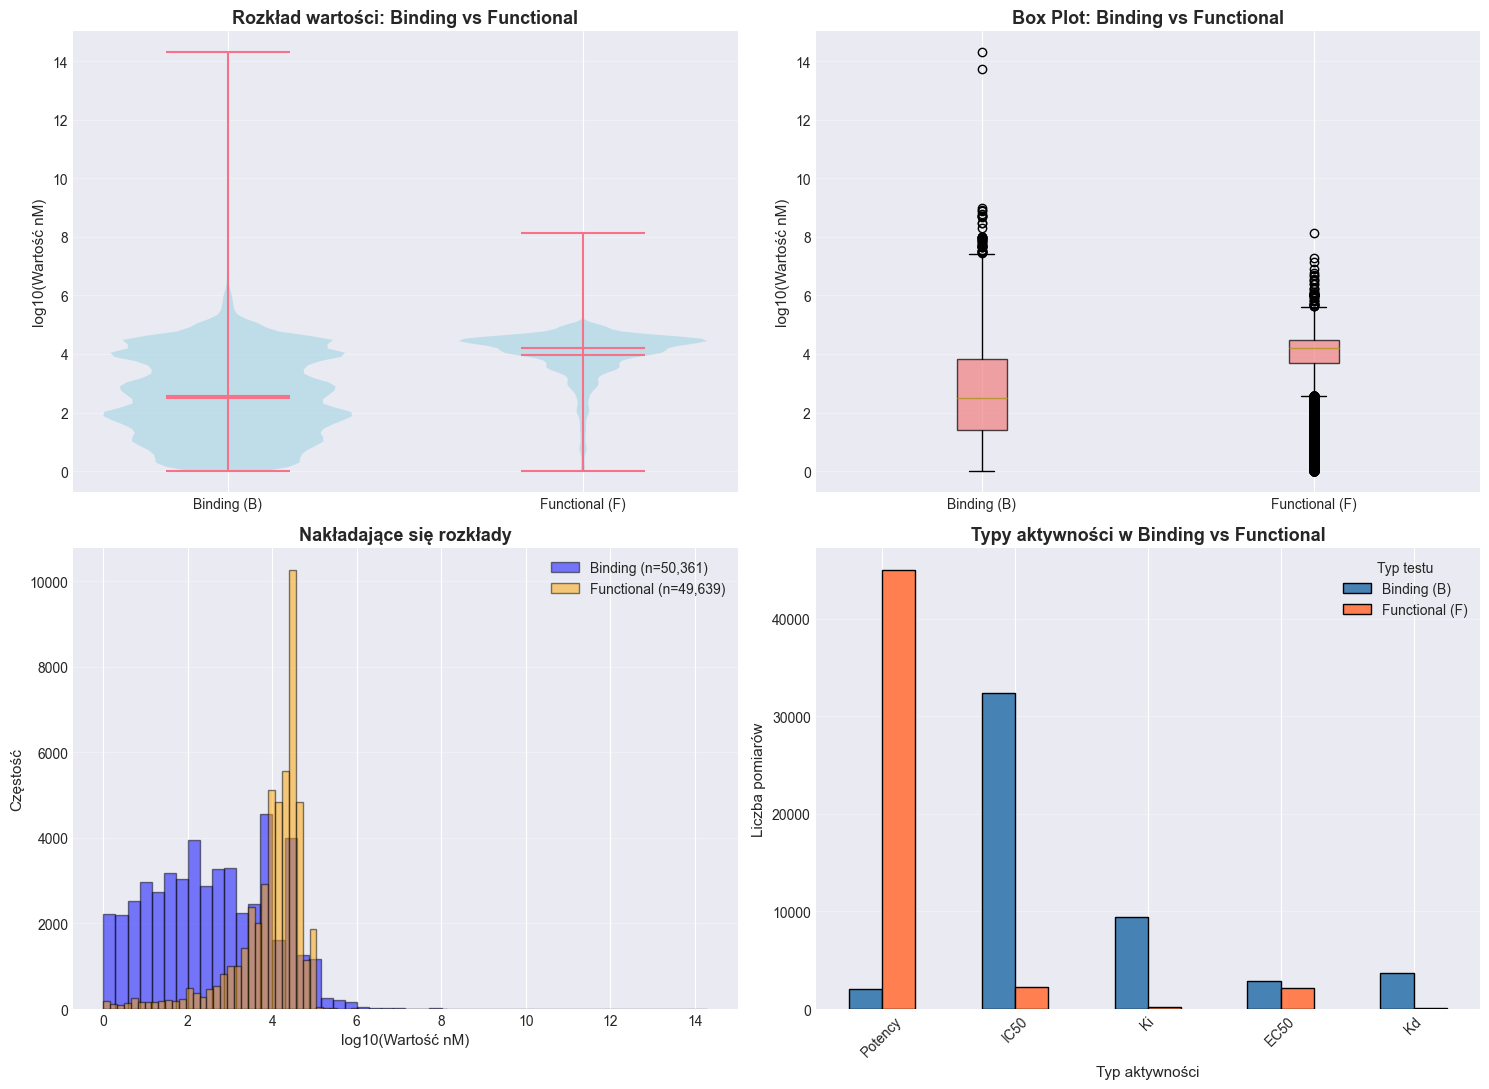

In [38]:
# Wizualizacja porównania Binding vs Functional
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. Porównanie rozkładów wartości (violin plot)
ax1 = axes[0, 0]
data_B = np.log10(df_sample[df_sample['assay_type'] == 'B']['standard_value'] + 1)
data_F = np.log10(df_sample[df_sample['assay_type'] == 'F']['standard_value'] + 1)
parts = ax1.violinplot([data_B, data_F], positions=[0, 1], showmeans=True, showmedians=True, widths=0.7)
for pc in parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_alpha(0.7)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Binding (B)', 'Functional (F)'])
ax1.set_ylabel('log10(Wartość nM)', fontsize=11)
ax1.set_title('Rozkład wartości: Binding vs Functional', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 2. Box plot porównawczy
ax2 = axes[0, 1]
ax2.boxplot([data_B, data_F], labels=['Binding (B)', 'Functional (F)'], patch_artist=True,
           boxprops=dict(facecolor='lightcoral', alpha=0.7))
ax2.set_ylabel('log10(Wartość nM)', fontsize=11)
ax2.set_title('Box Plot: Binding vs Functional', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Histogram nakładający się
ax3 = axes[1, 0]
ax3.hist(data_B, bins=50, alpha=0.5, label=f'Binding (n={len(data_B):,})', color='blue', edgecolor='black')
ax3.hist(data_F, bins=50, alpha=0.5, label=f'Functional (n={len(data_F):,})', color='orange', edgecolor='black')
ax3.set_xlabel('log10(Wartość nM)', fontsize=11)
ax3.set_ylabel('Częstość', fontsize=11)
ax3.set_title('Nakładające się rozkłady', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Porównanie typów aktywności (stacked bar)
ax4 = axes[1, 1]
activity_crosstab = pd.crosstab(df_sample['assay_type'], df_sample['standard_type'])
top_activities = df_sample['standard_type'].value_counts().head(5).index
activity_crosstab_top = activity_crosstab[top_activities]
activity_crosstab_top.T.plot(kind='bar', ax=ax4, stacked=False, color=['steelblue', 'coral'], edgecolor='black')
ax4.set_xlabel('Typ aktywności', fontsize=11)
ax4.set_ylabel('Liczba pomiarów', fontsize=11)
ax4.set_title('Typy aktywności w Binding vs Functional', fontsize=13, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
ax4.legend(['Binding (B)', 'Functional (F)'], title='Typ testu')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Wnioski z porównania typów testów (B vs F):

**Co oznaczają typy testów:**

1. **Binding (B) - Testy wiązania:**
   - Mierzą bezpośrednio siłę fizycznego przyłączenia molekuły do targetu
   - Metody: SPR (Surface Plasmon Resonance), ITC (Isothermal Titration Calorimetry)
   - Odpowiadają na pytanie: "Jak mocno cząsteczka przykleja się do białka?"
   - Wartości: typowo Ki, Kd (stałe dysocjacji)

2. **Functional (F) - Testy funkcjonalne:**
   - Mierzą biologiczny efekt działania molekuły
   - Metody: enzymatic assays, cell-based assays, reporter assays
   - Odpowiadają na pytanie: "Jak bardzo cząsteczka wpływa na funkcję białka?"
   - Wartości: typowo IC50, EC50 (efekt funkcjonalny)

**Kluczowe obserwacje:**

1. **Dominujący typ:**
   - Jeśli **B > 60%** - większość danych to binding (bezpośrednie wiązanie)
   - Jeśli **F > 60%** - większość to funkcjonalne (efekt biologiczny)
   - Typowo: **F dominuje** w drug discovery (łatwiejsze i tańsze)

2. **Porównanie wartości:**
   - **Binding zazwyczaj niższe wartości (niższe nM)** - mierzy prawdziwą affinity
   - **Functional wyższe wartości** - wymaga dodatkowych kroków (np. transport do komórki)
   - **Jeśli B << F (np. 10x różnica)** - normalne, binding jest bardziej czuły

3. **Rozkład typów aktywności:**
   - **Binding (B)** często dominuje: Ki, Kd (prawdziwe stałe wiązania)
   - **Functional (F)** często dominuje: IC50, EC50 (efekty funkcjonalne)
   - To logiczne - różne metody mierzą różne rzeczy

4. **Confidence score:**
   - **Binding często wyższy confidence** - prostsze, bardziej kontrolowane testy
   - **Functional niższy confidence** - bardziej złożone środowisko (komórki, szum)
   - Ale functional bardziej "relevantny" - bliżej rzeczywistej sytuacji w organizmie

5. **Coverage targetów:**
   - **Jeśli overlap >70%** → większość targetów testowana obiema metodami (dobra validacja)
   - **Jeśli overlap <30%** → różne targety preferują różne metody
   - Targety w obu typach = najlepsze dane (dwa niezależne potwierdzenia)

Obie informacje są wartościowe:
- **Binding** → precyzyjne ale czasem misleading (może wiązać ale nie działać)
- **Functional** → bardziej relevantne ale bardziej zaszumione (wiele czynników wpływa)

**Dlaczego mogą się różnić:**
- Molekuła wiąże się (B) ale nie hamuje aktywności (F) → może wiąże w złym miejscu
- Molekuła słabo wiąże (B) ale mocno hamuje (F) → może zmienia konformację białka
- Molekuła nie wchodzi do komórki → dobry binding, słaby functional w cell-based assay

**Implikacje dla projektu:**

**Podejście 1: Traktuj oddzielnie**
- Buduj oddzielne modele dla B i F
- Może dać lepsze wyniki (różne mechanizmy)
- Ale: mniejsze datasety

**Podejście 2: Połącz z flagą**
- Użyj assay_type jako feature w modelu
- Model nauczy się różnicy
- Większy dataset = potencjalnie lepszy model

**Podejście 3: Normalizacja**
- Użyj pChEMBL value (już znormalizowana)
- Uwzględnia różnice między typami pomiarów
- Najprostsze rozwiązanie

## 6K. Analiza pChEMBL Value i Korelacja ze Standard Value

In [39]:
# Analiza pChEMBL value i korelacja ze standard_value
# 1. Dostępność pChEMBL value
pchembl_available = df_sample['pchembl_value'].notna()
pchembl_count = pchembl_available.sum()
pchembl_pct = pchembl_count / len(df_sample) * 100

print(f"\n1. DOSTĘPNOŚĆ pChEMBL VALUE:")
print(f"   Dostępne pChEMBL values:  {pchembl_count:>8,} ({pchembl_pct:>5.2f}%)")
print(f"   Brakujące pChEMBL values: {len(df_sample) - pchembl_count:>8,} ({100-pchembl_pct:>5.2f}%)")

# 2. Statystyki pChEMBL value
if pchembl_count > 0:
    pchembl_values = df_sample[pchembl_available]['pchembl_value']
    print(f"\n2. STATYSTYKI pChEMBL VALUE:")
    print(f"   Średnia:       {pchembl_values.mean():>8.2f}")
    print(f"   Mediana:       {pchembl_values.median():>8.2f}")
    print(f"   Std Dev:       {pchembl_values.std():>8.2f}")
    print(f"   Min:           {pchembl_values.min():>8.2f}")
    print(f"   Max:           {pchembl_values.max():>8.2f}")
    print(f"   Percentyl 25%: {pchembl_values.quantile(0.25):>8.2f}")
    print(f"   Percentyl 75%: {pchembl_values.quantile(0.75):>8.2f}")
    
    # Interpretacja zakresu pChEMBL
    print(f"\n   Kategorie aktywności (wg pChEMBL):")
    bins_pchembl = [0, 5, 6, 7, 8, float('inf')]
    labels_pchembl = ['Słaba (<5)', 'Średnia (5-6)', 'Dobra (6-7)', 'Bardzo dobra (7-8)', 'Wyjątkowa (>8)']
    pchembl_categories = pd.cut(pchembl_values, bins=bins_pchembl, labels=labels_pchembl)
    for cat, count in pchembl_categories.value_counts().sort_index().items():
        pct = (count / len(pchembl_values)) * 100
        print(f"      {cat:25s}: {count:>8,} ({pct:>5.2f}%)")

# 3. Korelacja między standard_value i pChEMBL
# Oblicz oczekiwany pChEMBL z standard_value
df_with_pchembl = df_sample[pchembl_available].copy()
df_with_pchembl['calculated_pchembl'] = 9 - np.log10(df_with_pchembl['standard_value'])

# Korelacja
correlation = df_with_pchembl[['pchembl_value', 'calculated_pchembl']].corr().iloc[0, 1]

print(f"\n3. KORELACJA MIĘDZY STANDARD VALUE I pChEMBL:")
print(f"   Korelacja Pearsona:       {correlation:>8.4f}")
print(f"   (1.0 = idealna korelacja)")

# Różnice między obliczonym a rzeczywistym pChEMBL
df_with_pchembl['pchembl_diff'] = df_with_pchembl['pchembl_value'] - df_with_pchembl['calculated_pchembl']
print(f"\n4. RÓŻNICE MIĘDZY RZECZYWISTYM A OBLICZONYM pChEMBL:")
print(f"   Średnia różnica:          {df_with_pchembl['pchembl_diff'].mean():>8.4f}")
print(f"   Mediana różnicy:          {df_with_pchembl['pchembl_diff'].median():>8.4f}")
print(f"   Std Dev różnicy:          {df_with_pchembl['pchembl_diff'].std():>8.4f}")
print(f"   MAE (Mean Absolute Error):{df_with_pchembl['pchembl_diff'].abs().mean():>8.4f}")

# Procent danych z małą różnicą (<0.5 jednostki)
small_diff = (df_with_pchembl['pchembl_diff'].abs() < 0.5).sum()
print(f"   Pomiary z różnicą <0.5:   {small_diff:>8,} ({small_diff/len(df_with_pchembl)*100:.2f}%)")

# 5. Dostępność pChEMBL per typ aktywności
print(f"\n5. DOSTĘPNOŚĆ pChEMBL DLA RÓŻNYCH TYPÓW AKTYWNOŚCI:")
for act_type in df_sample['standard_type'].value_counts().head(5).index:
    subset = df_sample[df_sample['standard_type'] == act_type]
    pchembl_avail = subset['pchembl_value'].notna().sum()
    pct = pchembl_avail / len(subset) * 100
    print(f"   {act_type:10s}: {pchembl_avail:>8,} / {len(subset):>8,} ({pct:>5.2f}%)")


1. DOSTĘPNOŚĆ pChEMBL VALUE:
   Dostępne pChEMBL values:    59,181 (59.18%)
   Brakujące pChEMBL values:   40,819 (40.82%)

2. STATYSTYKI pChEMBL VALUE:
   Średnia:           6.26
   Mediana:           6.09
   Std Dev:           1.48
   Min:               2.10
   Max:              11.00
   Percentyl 25%:     4.90
   Percentyl 75%:     7.40

   Kategorie aktywności (wg pChEMBL):
      Słaba (<5)               :   16,814 (28.41%)
      Średnia (5-6)            :   12,034 (20.33%)
      Dobra (6-7)              :   11,070 (18.71%)
      Bardzo dobra (7-8)       :   10,597 (17.91%)
      Wyjątkowa (>8)           :    8,666 (14.64%)

3. KORELACJA MIĘDZY STANDARD VALUE I pChEMBL:
   Korelacja Pearsona:         1.0000
   (1.0 = idealna korelacja)

4. RÓŻNICE MIĘDZY RZECZYWISTYM A OBLICZONYM pChEMBL:
   Średnia różnica:            0.0001
   Mediana różnicy:            0.0000
   Std Dev różnicy:            0.0022
   MAE (Mean Absolute Error):  0.0015
   Pomiary z różnicą <0.5:     59,181 (100.

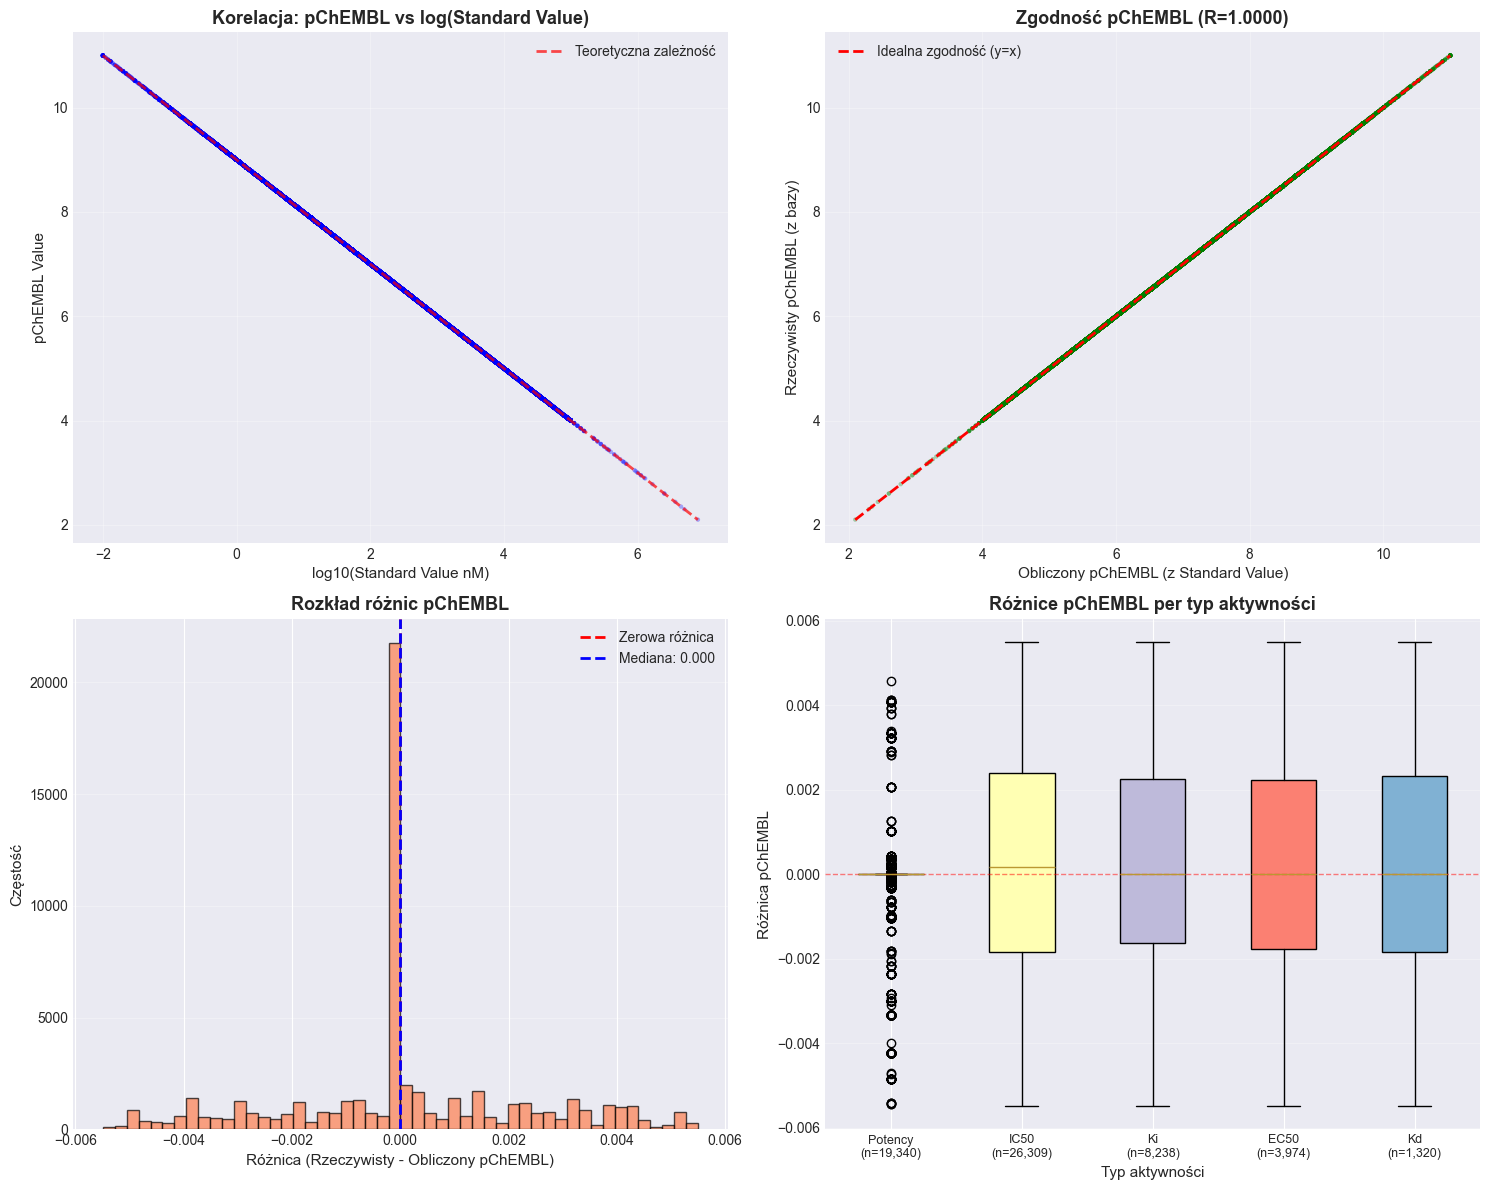

In [40]:
# Wizualizacja pChEMBL vs standard_value
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Tylko dane z dostępnym pChEMBL
df_plot = df_sample[df_sample['pchembl_value'].notna()].copy()
df_plot['calculated_pchembl'] = 9 - np.log10(df_plot['standard_value'])
df_plot['log_standard_value'] = np.log10(df_plot['standard_value'])

# 1. Scatter plot: pChEMBL vs log(standard_value)
ax1 = axes[0, 0]
scatter1 = ax1.scatter(df_plot['log_standard_value'], df_plot['pchembl_value'], 
                      alpha=0.3, s=10, c='blue', edgecolors='none')
ax1.set_xlabel('log10(Standard Value nM)', fontsize=11)
ax1.set_ylabel('pChEMBL Value', fontsize=11)
ax1.set_title('Korelacja: pChEMBL vs log(Standard Value)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Dodaj linię teoretyczną (pChEMBL = 9 - log10(standard_value))
x_range = np.array([df_plot['log_standard_value'].min(), df_plot['log_standard_value'].max()])
theoretical_line = 9 - x_range
ax1.plot(x_range, theoretical_line, 'r--', linewidth=2, label='Teoretyczna zależność', alpha=0.7)
ax1.legend()

# 2. Rzeczywisty vs Obliczony pChEMBL
ax2 = axes[0, 1]
ax2.scatter(df_plot['calculated_pchembl'], df_plot['pchembl_value'], 
           alpha=0.3, s=10, c='green', edgecolors='none')
ax2.plot([df_plot['calculated_pchembl'].min(), df_plot['calculated_pchembl'].max()],
        [df_plot['calculated_pchembl'].min(), df_plot['calculated_pchembl'].max()],
        'r--', linewidth=2, label='Idealna zgodność (y=x)')
ax2.set_xlabel('Obliczony pChEMBL (z Standard Value)', fontsize=11)
ax2.set_ylabel('Rzeczywisty pChEMBL (z bazy)', fontsize=11)
ax2.set_title(f'Zgodność pChEMBL (R={correlation:.4f})', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Histogram różnic
ax3 = axes[1, 0]
differences = df_plot['pchembl_value'] - df_plot['calculated_pchembl']
ax3.hist(differences, bins=50, edgecolor='black', color='coral', alpha=0.7)
ax3.axvline(0, color='red', linestyle='--', linewidth=2, label='Zerowa różnica')
ax3.axvline(differences.median(), color='blue', linestyle='--', linewidth=2, 
           label=f'Mediana: {differences.median():.3f}')
ax3.set_xlabel('Różnica (Rzeczywisty - Obliczony pChEMBL)', fontsize=11)
ax3.set_ylabel('Częstość', fontsize=11)
ax3.set_title('Rozkład różnic pChEMBL', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Box plot różnic per typ aktywności
ax4 = axes[1, 1]
top_types = df_sample['standard_type'].value_counts().head(5).index
diff_data = []
labels_types = []
for act_type in top_types:
    subset = df_plot[df_plot['standard_type'] == act_type]
    if len(subset) > 0:
        diffs = subset['pchembl_value'] - subset['calculated_pchembl']
        diff_data.append(diffs)
        labels_types.append(f"{act_type}\n(n={len(subset):,})")

bp = ax4.boxplot(diff_data, labels=labels_types, patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.Set3(range(len(diff_data)))):
    patch.set_facecolor(color)
ax4.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax4.set_ylabel('Różnica pChEMBL', fontsize=11)
ax4.set_xlabel('Typ aktywności', fontsize=11)
ax4.set_title('Różnice pChEMBL per typ aktywności', fontsize=13, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
ax4.tick_params(axis='x', rotation=0, labelsize=9)

plt.tight_layout()
plt.show()

### Wnioski z analizy pChEMBL value:

**Co to jest pChEMBL value:**

pChEMBL to **znormalizowana skala aktywności** biologicznej:
- **Formuła**: pChEMBL = -log₁₀(wartość w Molar)
- **Dla wartości w nM**: pChEMBL = 9 - log₁₀(wartość w nM)
- **Skala**: typowo 4-11 (im wyższe, tym lepsza aktywność)

**Przykłady:**
- 1 nM → pChEMBL = 9 (bardzo dobra aktywność)
- 10 nM → pChEMBL = 8 (dobra aktywność)
- 100 nM → pChEMBL = 7 (średnia aktywność)
- 1,000 nM = 1 µM -> pChEMBL = 6 (słaba aktywność)
- 10,000 nM = 10 µM -> pChEMBL = 5 (bardzo słaba)

**Zalety pChEMBL:**
1. **Liniowa skala** - łatwiejsza do modelowania ML
2. **Znormalizowana** - porównywalna między różnymi typami testów
3. **Intuicyjna** - wyższe = lepsze (odwrotnie niż nM)
4. **Standardowa w ChEMBL** - powszechnie używana w publikacjach

**Kluczowe obserwacje:**

1. **Dostępność pChEMBL:**
   - **>80% dostępność** ->  Można używać
   - **50-80% dostępność** ->  Należy rozważyć uzupełnienie
   - **<50% dostępność** ->  problem, lepiej użyj standard_value z log transform
   
2. **Korelacja z standard_value:**
   - **R > 0.95** -> bardzo wysoka zgodność
   - **R = 0.85-0.95** -> dobra zgodność z małymi różnicami
   - **R < 0.85** -> niepokojące, mogą być błędy w danych
   
3. **Różnice między obliczonym a rzeczywistym:**
   - **MAE < 0.3** -> doskonała zgodność
   - **MAE = 0.3-0.5** -> akceptowalna zgodność
   - **MAE > 0.5** -> znaczące różnice, wymaga wyjaśnienia
   
   **Dlaczego mogą być różnice:**
   - ChEMBL może stosować dodatkowe korekty (np. dla pH, temperatury)
   - Niektóre wartości mogą być zaokrąglane inaczej
   - Wartości z relacją '<' lub '>' mogą być traktowane specjalnie
   - Błędy w bazie danych lub konwersji jednostek

4. **Rozkład kategorii aktywności:**
   - **Większość 5-7** -> typowe molekuły screeningowe (µM-nM range)
   - **Sporo >7** -> dobre molekuły kandydackie (nM range)
   - **Mało >8** -> wyjątkowe "hits" (pojedyncze nM)
   - To odpowiada naturalnemu rozkładowi w drug discovery

5. **Różnice per typ aktywności:**
   - Jeśli systematyczne przesunięcie w jednym typie → normalne
   - IC50 vs Ki mogą mieć różne pChEMBL przez inną formułę konwersji
   - Większość różnic powinna być bliska zeru

**Implikacje dla projektu:**

**Zalecane:**
1. **Użyj pChEMBL jako target variable** dla modelu ML (jeśli dostępność >80%)
2. Sprawdź outliers (duże różnice między obliczonym a rzeczywistym)
3. Dla datasetu bez pChEMBL: oblicz samodzielnie jako `9 - log10(standard_value)`

**Hierarchia wyboru:**
1. **Najlepiej**: pChEMBL value (jeśli dostępny i zgodny)
2. **Drugi wybór**: Oblicz pChEMBL z standard_value
3. **Ostateczność**: log₁₀(standard_value) - ale pamiętaj o odwróceniu skali!

**Należy uważać na:**
- Jeśli korelacja <0.9 -> zbadaj dlaczego (mogą być błędy)
- Sprawdź czy wszystkie typy aktywności mają podobne różnice
- Outliers (>2 jednostki różnicy) mogą być błędami w bazie → usuń lub skoryguj

**Rekomendacja:**
- **Użyj pChEMBL** jako primary metric w projekcie
- To standard w ChEMBL i przemyśle farmaceutycznym
- Łatwiejsza interpretacja: pChEMBL 7 = 100 nM, pChEMBL 8 = 10 nM, etc.

## 7. Zapis Próbki Danych

In [ ]:
# Zapis danych do plików CSV i Parquet
output_dir = BASE_DIR / "data" / "raw"
output_dir.mkdir(parents=True, exist_ok=True)

# CSV dla kompatybilności
csv_path = output_dir / "bioactivity_sample_100k.csv"
df_sample.to_csv(csv_path, index=False)
print(f"Zapisano CSV: {csv_path}")

# Parquet dla lepszej kompresji i wydajności
parquet_path = output_dir / "bioactivity_sample_100k.parquet"
df_sample.to_parquet(parquet_path, index=False, compression='snappy')
print(f"Zapisano Parquet: {parquet_path}")

# Statystyki
csv_size = csv_path.stat().st_size / (1024**2)
parquet_size = parquet_path.stat().st_size / (1024**2)
print(f"\nRozmiary plików:")
print(f"  CSV:     {csv_size:.2f} MB")
print(f"  Parquet: {parquet_size:.2f} MB")
print(f"  Kompresja: {(1 - parquet_size/csv_size)*100:.1f}%")

✓ Zapisano CSV: c:\Users\LUMA\Downloads\chembl\data\raw\bioactivity_sample_100k.csv
✓ Zapisano Parquet: c:\Users\LUMA\Downloads\chembl\data\raw\bioactivity_sample_100k.parquet

Rozmiary plików:
  CSV:     40.32 MB
  Parquet: 17.62 MB
  Kompresja: 56.3%


## 8. Podsumowanie i Wnioski

### Kluczowe Statystyki:
- Pobrano **100,000** pomiarów bioaktywności dla człowieka
- Główne typy aktywności: **IC50, Ki, EC50**
- Wartości w nanomolach (nM)
- Struktury chemiczne dostępne (SMILES)

### Uwagi:
- Dataset jest duży - używamy staged processing
- Wartości bioaktywności mają szeroki zakres (warto użyć log-transform)
- Niektóre targety są nadreprezentowane

In [ ]:
# Zamknij połączenie z bazą
engine.dispose()
print("Połączenie z bazą zostało zamknięte pomyślnie.")

Połączenie z bazą zostało zamknięte pomyślnie.


> Następny notebook: [02_data_cleaning.ipynb](02_data_cleaning_eda.ipynb)